# Early Completion Risk Modeling: Progress-Aware Prediction and Engagement-Only Robustness Check

## Project Overview

### Objective

This project represents **Part 3** of the analytical workflow for the Interactive **Data Analysis in R Course** on **Stepik**.

The main objective of this phase is to build a supervised machine learning workflow that estimates users' likelihood of eventual course completion based on behavioral signals observed during the first 10 days of activity.

Part 1 identified the main product problem as an early **Activation Gap**: many users disengage before moving from passive content consumption into meaningful practical engagement. Part 2 showed that resolved learners can be grouped into three business-actionable behavioral segments: **Passive Users**, **Steady Learners**, and **Burst Learners**.

Building on these findings, Part 3 moves from descriptive and exploratory analysis to predictive modeling. The goal is to estimate each user's probability of reaching the course completion threshold and use this estimate to support proactive retention prioritization.

The model output is:

`P(Completed)`

For business use, this probability is inverted into a non-completion risk score:

`Risk_Not_Completed = 1 - P(Completed)`

This score is used as a **ranking and prioritization signal**, not as a perfectly calibrated probability of non-completion. Users with lower predicted completion probability are treated as higher-priority candidates for retention support.

---

### Project Context

This analytical workflow is organized into three connected stages.

**Part 1: Product Analysis, EDA, and Activation Gap Diagnosis**  
The first phase analyzed raw Stepik event and submission logs to identify where users disengage. It showed that the largest observed loss happens before the first meaningful practical action, especially before users start or submit assignments. This early drop-off was summarized as the **Activation Gap**.

Part 1 also prepared the downstream analytical foundation by applying P99-based filtering, excluding unresolved `in_progress` users, constructing user-level behavioral features, and exporting processed datasets for segmentation and prediction.

**Part 2: Behavioral Segmentation and Completion Outcome Analysis**  
The second phase used K-means clustering to identify behaviorally distinct learner groups within the resolved `model_base` sample. The final primary segmentation used **K = 3**, because it provided larger, more interpretable, and more business-actionable user groups.

The resulting segments were:

- **Passive Users** — minimal engagement and almost no practical progress.
- **Steady Learners** — sustained participation with moderate practical activity.
- **Burst Learners** — concentrated high-intensity activity and higher per-day productivity.

Completion outcomes were analyzed after clustering. More engaged segments showed relatively higher completion shares, although `Not_Completed` remained the dominant outcome across all segments.

**Part 3: Supervised Completion Risk Modeling**  
This phase uses early 10-day behavioral signals to estimate completion likelihood and rank users by non-completion risk. The goal is not only to evaluate predictive performance, but also to connect model outputs to practical retention prioritization.

Cluster labels from Part 2 are treated as exploratory business interpretation. They are not used as direct supervised-model inputs, in order to keep the prediction workflow focused on observable early behavioral signals.

---

### Data Description

The modeling workflow uses two preprocessed user-level datasets derived from the original Stepik event and submission logs.

Both datasets are based on the resolved `model_base` sample prepared in Part 1. This sample excludes:

- P99-defined extreme high-activity users,
- users still marked as unresolved `in_progress` at the dataset snapshot.

This ensures that the prediction workflow focuses on resolved learner trajectories and uses the same analytical population as the behavioral segmentation in Part 2.

**1. `prediction_features_10d_model_base.csv`**

This dataset contains user-level behavioral features calculated from the first 10 days of activity for users in `model_base`.

**Granularity**

- **1 row = 1 user**
- **Total users:** 17,657

Main feature groups include:

**General engagement, recency, and practical-start behavior**

- `n_viewed_all`
- `n_started_practical`
- `active_days`
- `days_since_last_action`

**Progress-aware, submission, score, and productivity-related features**

- `n_passed_all`
- `n_passed_practical`
- `n_submissions`
- `submission_correct_rate`
- `score_per_active_day`
- `steps_per_active_day`

The progress-aware setting uses both general engagement and progress-related features. The leakage-reduced engagement-only setting excludes direct pass-, score-, submission-success-, and progress-proxy variables.

**2. `completion_target_model_base.csv`**

This dataset contains the final binary completion label for each user:

- `Completed`
- `Not_Completed`

The two datasets are merged by `user_id`, with integrity checks ensuring one row per user, no duplicate users, no missing targets, and no row loss during the merge.

---

### Prediction Target

Course completion is defined by the platform's grading rule:

- **Completed**: user reaches at least **75 points**.
- **Not_Completed**: user remains below **75 points**.

The course has a maximum possible score of **88 points**, with **85+ points** corresponding to honor-level performance. For this modeling task, completion is treated as a binary outcome, and the distinction between standard and honor completion is not modeled separately.

Because completion is score-based, special attention is required when interpreting predictors related to early progress, passed steps, submissions, success rates, and score accumulation. These variables may be highly informative for practical early monitoring, but they can also act as progress-based target proxies.

During dataset preparation, an early-threshold diagnostic showed that a small share of users had already reached the 75-point completion threshold within the first 10-day observation window. This confirms that the main feature set should be interpreted as **progress-aware early monitoring**, not as a fully leakage-free future-prediction setup.

For this reason, the project evaluates two complementary prediction settings.

**1. Progress-aware prediction setting**  
This is the primary practical modeling setting. It uses early behavioral and progress-related features from the first 10 days, including activity, practical engagement, passed steps, submissions, productivity, and recency. This setting is designed for early progress monitoring and operational risk ranking.

**2. Leakage-reduced engagement-only setting**  
This is a secondary robustness check. It removes direct score/progress proxy features and uses only early engagement, recency, and practical-start behavior. This setting evaluates whether predictive signal remains beyond direct progress accumulation.

The target definition is the same in both settings. The difference lies in the feature set and the methodological interpretation.

In addition, a targeted ablation check is included to assess whether the progress-aware models depend too strongly on the dominant early progress feature `n_passed_practical`.

---

### Modeling Framing

Although the business objective is to prioritize users at risk of non-completion, the technical modeling task is framed as completion prediction, with `Completed` treated as the positive class.

This choice is intentional because `Completed` is the rare and more informative outcome. Since `Not_Completed` represents the large majority of users, treating `Not_Completed` as the positive class would make many metrics appear artificially strong due to majority-class dominance.

Predicting the rare `Completed` outcome makes metrics such as PR-AUC, Precision, Recall, F1-score, and F2-score more informative for evaluating whether the models capture meaningful completion signal.

This creates an important distinction between **model evaluation** and **business use**.

The model output is:

`P(Completed)`

Model metrics such as PR-AUC, Recall, Precision, F1, and F2 are calculated for the rare `Completed` class. They evaluate how well the model identifies users with stronger completion signal.

For business use, the same model output is inverted into a non-completion risk-ranking score:

`Risk_Not_Completed = 1 - P(Completed)`

Users with lower predicted completion probability are treated as higher-priority candidates for retention support. In other words, the model is technically evaluated as a completion-prediction model, while the business policy uses the weakest end of the completion-signal distribution to prioritize users at risk of non-completion.

Therefore, threshold-based metrics such as F2 should not be interpreted as direct non-completion metrics. They measure completion-signal detection for the rare `Completed` class. The downstream intervention policy is evaluated separately by ranking users according to the inverted risk score.

This score should be interpreted as a **ranking and prioritization signal**, not as a perfectly calibrated probability of non-completion or a causal estimate of intervention effectiveness.

---

### Methodological Strategy

The workflow follows a structured supervised learning process.

1. **Data loading and integrity checks**
   - Load the 10-day prediction feature dataset and completion target dataset.
   - Verify dataset dimensions.
   - Check user-level uniqueness.
   - Merge features and target.
   - Validate missing values, duplicates, feature boundaries, funnel logic, and ratio logic.

2. **Train / validation / test split**
   - Use a stratified **60 / 20 / 20** split.
   - Preserve the rare `Completed` class distribution across all subsets.
   - Apply the same split to both the progress-aware and engagement-only settings.
   - Use the validation set as a model-development set for feature comparison, tuning, threshold selection, and model selection.
   - Keep the test set fully reserved for final holdout evaluation.

3. **Training-set exploratory analysis**
   - Compare early behavioral features between `Completed` and `Not_Completed` users.
   - Review class imbalance.
   - Evaluate univariate ROC-AUC and PR-AUC.
   - Check correlation and redundancy among predictors.
   - Interpret progress-related signals cautiously because completion is score-based.

4. **Progress-aware baseline model comparison**
   - Train and compare Random Forest and XGBoost models on the original progress-aware feature set.
   - Evaluate multiple imbalance-handling strategies:
     - baseline model,
     - class weighting,
     - 1:3 resampling,
     - 1:1 resampling.

5. **Progress-aware feature engineering**
   - Add activation flags, behavioral ratio/intensity features, practical-success indicators, practice-intensity features, and recency indicators.
   - Compare original and engineered progress-aware feature sets on validation performance.

6. **Targeted tuning of progress-aware candidates**
   - Tune selected model families only:
     - XGBoost for ranking-oriented performance,
     - Random Forest as a threshold-oriented intervention challenger.
   - Use validation results for model and threshold selection.
   - Interpret validation metrics as development diagnostics, not as final generalization estimates.

7. **Progress-aware final model selection**
   - Select the primary probability-based ranking model for `P(Completed)`.
   - Retain a threshold-oriented intervention challenger if it provides a useful Recall/F2 trade-off for completion-signal detection.
   - Freeze selected models and validation thresholds before final test evaluation.

8. **Final holdout evaluation of progress-aware models**
   - Evaluate selected progress-aware models on the reserved test set.
   - Report ROC-AUC, PR-AUC, Recall, Precision, F1, F2, FPR, and FNR.
   - Interpret these metrics as completion-prediction metrics, with `Completed` as the positive class.

9. **Risk policy analysis**
   - Convert predicted completion probability into the non-completion risk score:
     `Risk_Not_Completed = 1 - P(Completed)`.
   - Rank users by estimated non-completion risk.
   - Evaluate top-risk intervention groups, such as top 5%, 10%, 20%, and 30%.
   - Interpret these results as prioritization diagnostics, not as causal evidence of intervention effectiveness.

10. **Calibration and interpretability**
   - Assess probability calibration using calibration bins and Brier Score.
   - Interpret model behavior through feature importance.
   - Treat feature importance from progress-aware models as evidence of early progress alignment, not as fully leakage-free causal explanation.

11. **Dominant progress-feature ablation check**
   - Remove the strongest progress-related predictor, `n_passed_practical`.
   - Re-evaluate the selected model families on the reduced progress-aware feature set.
   - Use the results as a sensitivity check, not as a separate model-selection cycle.
   - Assess whether model performance depends mainly on one dominant progress feature or remains supported by broader early behavioral and progress signals.

12. **Leakage-reduced engagement-only robustness check**
   - Remove direct score/progress proxy features.
   - Re-evaluate selected model families using engagement-only features.
   - Compare engagement-only performance against progress-aware models.
   - Assess how much predictive signal remains beyond direct progress accumulation.

13. **Model and results registry**
   - Collect the main trained model objects and result tables.
   - Export model artifacts and result tables for reproducibility.
   - Keep the registry separate from model selection decisions.

---

### Key Modeling Questions

This project addresses five main questions:

1. **Can early 10-day behavior and progress signals help rank users by likelihood of eventual completion?**

2. **Which early signals are most informative: activity volume, practical activation, progress, productivity, or recency?**

3. **How much of the model performance depends on progress-related predictors that are close to the score-based target definition?**

4. **Does model performance remain stable when the dominant progress feature `n_passed_practical` is removed?**

5. **Can a leakage-reduced engagement-only model still retain useful predictive signal after removing direct score/progress proxy features?**

---

### Key Findings

The analysis identifies several core findings.

**Early 10-day behavior contains strong completion signal.**  
Users who eventually complete the course show stronger early activity, more practical engagement, higher productivity, and more recent activity within the observation window.

**The progress-aware models provide the strongest operational performance.**  
The selected progress-aware models outperform the leakage-reduced engagement-only alternatives overall, especially in ranking quality and threshold-based detection of completion signal.

**XGB_Baseline_Tuned is the primary ranking-oriented model.**  
This model provides the strongest probability-based ranking performance among the selected progress-aware candidates and is therefore used as the primary model for estimating `P(Completed)`.

**RF_Resampled_1_1_Tuned is retained as a threshold-oriented challenger.**  
The tuned Random Forest model provides a useful alternative for threshold-based intervention analysis, especially where higher Recall/F2 for the rare `Completed` class is operationally relevant.

**The strongest individual predictor is `n_passed_practical`.**  
Feature importance shows that early practical progress is the dominant signal. This is expected because the target is score-based and practical progress is closely aligned with eventual completion.

**The model is not driven by one feature alone.**  
The ablation check shows that removing `n_passed_practical` decreases performance only moderately. Predictive signal remains supported by related early progress, activity, productivity, and recency features.

**Engagement-only models retain meaningful signal.**  
After removing direct score/progress proxy variables, performance decreases, but engagement, recency, and practical-start behavior still provide useful predictive information.

**Model probabilities should be interpreted cautiously.**  
Calibration diagnostics show that predicted probabilities are not perfectly calibrated. The scores are therefore most appropriate for ranking and prioritization rather than literal probability interpretation.

**The results support the Activation Gap interpretation.**  
Users with weak early practical activation, low progress, and early inactivity receive lower predicted completion probability and therefore higher non-completion risk scores.

---

### Expected Business Use

The final model output can support retention prioritization during the early course period.

Users with low predicted `P(Completed)` can be assigned to risk-based intervention tiers, such as automated nudges, first-task prompts, skeleton-code support, progress feedback, or inactivity reminders.

The goal is not simply to identify non-completers, since non-completion is already the dominant outcome. Instead, the model helps prioritize users with the weakest early completion signals and avoid unnecessary interventions for users who are more likely to complete.

The primary operational model is the progress-aware risk-ranking model, because it is designed for practical early monitoring and intervention prioritization. It uses early behavioral and progress-related signals to identify users who appear clearly on or off track during the first 10 days.

The engagement-only models are not intended to replace the primary progress-aware models. They serve as a robustness check showing whether early behavioral signal remains after reducing target-proxy risk.

The additional ablation check helps assess whether the progress-aware model signal is concentrated in one dominant progress variable or whether broader early behavioral and progress features still support prediction after that variable is removed.

The model should not be treated as a replacement for product experimentation. Instead, it provides a data-driven decision-support layer for identifying users who may benefit from earlier, more targeted retention actions. Future A/B testing would be required to determine whether the recommended interventions actually improve retention and completion outcomes.

---

### Business Risk Scoring and Retention Strategy

The final modeling results can be translated into a practical retention strategy through a non-completion risk score:

`Risk_Not_Completed = 1 - P(Completed)`

This business score is derived from a model that is technically trained to predict `Completed`. This is intentional: `Completed` is the rare and informative class, so model metrics evaluate how well the model captures completion signal. Retention targeting then uses the opposite end of that signal distribution: users with the lowest `P(Completed)` are treated as highest non-completion risk.

Instead of treating the model output as a hard binary prediction, the product team can use the score to create intervention tiers.

| Risk tier | Suggested segment | Behavioral profile | Recommended intervention |
|---|---|---|---|
| Critical risk | Top 5% highest risk | Very low predicted completion probability; no or very weak early progress; little practical activation; early inactivity likely | Immediate automated nudge, first-task prompt, reminder to continue, simplified entry path |
| High risk | Top 10% highest risk | Strong non-completion signal; weak progress accumulation; limited or missing practical engagement | Onboarding support, first-submission guidance, skeleton code, motivational prompt |
| Medium-high risk | Top 20% highest risk | Some activity may exist, but progress and engagement are not stable enough | Progress feedback, next-step recommendation, task hints, reminder after inactivity |
| Broad risk pool | Top 30% highest risk | Wider group with elevated non-completion risk and weaker early completion trajectory | Low-cost automated campaign, reactivation email, general course navigation support |
| Lower risk | Remaining users | Higher predicted completion probability, stronger early progress, or more stable engagement | Minimal intervention; optional certificate or achievement-oriented motivation |

The two final progress-aware models support different operational roles.

**XGB_Baseline_Tuned** is used as the primary ranking-oriented model because it provides the strongest ranking performance on the final holdout test set. It is therefore best suited for probability-based risk ranking and prioritizing users by predicted non-completion risk.

**RF_Resampled_1_1_Tuned** is used as a threshold-oriented intervention challenger because it provides an alternative way to separate users with stronger versus weaker completion signal. Its probabilities should be treated mainly as relative scores rather than calibrated probabilities.

---

### Assumptions & Limitations

**Assumptions**

- The processed datasets correctly represent the resolved analytical sample `model_base`.
- The 10-day observation window captures meaningful early behavioral signal.
- `Completed` is correctly defined by the platform rule of reaching at least 75 points.
- Treating `Completed` as the positive class is appropriate because it is the rare and more informative outcome.
- Stratified train/validation/test splitting preserves the rare-class distribution sufficiently for model comparison and final evaluation.
- Tree-based models such as Random Forest and XGBoost are suitable for modeling nonlinear relationships in the early behavioral feature space.
- Predicted scores are used primarily for ranking and prioritization, not as causal estimates.

**Limitations**

- The main progress-aware models use pass-, score-, submission-, success-, and productivity-related predictors. Because completion is score-based, these variables can act as target proxies.
- A small share of users already reached the completion threshold within the first 10-day observation window. This confirms that the progress-aware setting should be interpreted as early monitoring rather than fully leakage-free future prediction.
- The `n_passed_practical` ablation check reduces this concern partly, but it does not remove the broader progress-aware nature of the feature set.
- The engagement-only robustness check shows that predictive signal remains after reducing target-proxy risk, but performance is weaker than in the progress-aware setting.
- Predicted probabilities are not perfectly calibrated. They should be interpreted mainly as ranking scores.
- The validation set is used for several development decisions, including feature-set comparison, model comparison, tuning, threshold selection, and model selection. Therefore, validation metrics are treated as development diagnostics, while final performance is assessed on the reserved test set.
- The model is trained on historical data from a specific course period. If the course structure, scoring rules, platform design, or learner population changes, model performance should be monitored and revalidated.
- The model identifies users with high non-completion risk, but it does not estimate intervention effectiveness. A future A/B test would be required to measure whether interventions actually improve retention and completion.
- Future production work should include monitoring for data drift, probability calibration, performance by learner segment, and periodic retraining.

---

### Final Project Conclusion

This project shows that early course behavior contains strong predictive signal for eventual completion. Even within the first 10 days, user activity patterns, early progress, practical activation, productivity, and recency can distinguish users who are on track to complete the course from users who are likely to disengage.

Because course completion is defined by reaching at least 75 points, the main models should be interpreted as **progress-aware completion risk models**. Some of the strongest predictors are directly related to early progress and score accumulation. Therefore, the main model results do not represent a fully leakage-free prediction setting, but rather a practical early-progress monitoring approach.

The strongest predictors are related to practical activation, early progress, productivity, and recency. This supports the **Activation Gap** identified in Part 1: users are at higher risk when they fail to move from passive viewing into active practical engagement and measurable progress during the first 10 days.

The additional ablation and engagement-only robustness checks provide important qualification. They show that the strongest model performance partly depends on progress-related features, but engagement, recency, and practical-start behavior also carry meaningful predictive signal.

The final modeling strategy uses two complementary progress-aware models:

- **XGB_Baseline_Tuned** as the primary model for ranking users by `P(Completed)` and deriving the inverted non-completion risk score.
- **RF_Resampled_1_1_Tuned** as a threshold-oriented intervention challenger for broader retention scenarios.

In both cases, the models are evaluated technically as completion-prediction models, while business intervention targeting is based on the inverted score:

`Risk_Not_Completed = 1 - P(Completed)`

From a business perspective, the model enables a shift from retrospective churn analysis to proactive retention management. Users can be scored during the first 10 days and assigned to risk-based intervention tiers before disengagement becomes permanent.

However, these scores should be interpreted as progress-aware risk rankings rather than perfectly calibrated causal estimates of intervention effectiveness.

---

In [1]:
# Environment Setup
if (!requireNamespace("pacman", quietly = TRUE)) install.packages("pacman")

In [2]:
pacman::p_load(data.table, dplyr, caret, ggplot2, tidyr, corrplot, randomForest, pROC, xgboost, MLmetrics)

---

## Data Loading & Pre-Split Integrity Audit

In [8]:
# Project root 
project_root <- ".."

In [9]:
# Project paths
data_dir <- file.path(project_root, "data")
processed_data_dir <- file.path(data_dir, "processed")

In [10]:
# Using data.table::fread for high-performance data loading
prediction_features_10d_model_base <- fread(file.path(processed_data_dir, "prediction_features_10d_model_base.csv"))
completion_target_model_base<- fread(file.path(processed_data_dir, "completion_target_model_base.csv"))

In [11]:
# Display memory usage for the processed prediction feature and target datasets
cat("prediction_features_10d_model_base size:", format(object.size(prediction_features_10d_model_base), units = "MB"), "\n")
cat("completion_target_model_base size:", format(object.size(completion_target_model_base), units = "MB"), "\n")

prediction_features_10d_model_base size: 0.9 Mb 
completion_target_model_base size: 0.2 Mb 


In [12]:
# Verify dataset dimensions and granularity
# Expected: 17,657  rows and 11 columns
dim(prediction_features_10d_model_base)

# Expected: 17,657  rows and 2 columns
dim(completion_target_model_base)

[1] 17657    11

[1] 17657     2

In [13]:
# Verification: Every row must represent one unique user (Primary Key check)
stopifnot(nrow(prediction_features_10d_model_base) == n_distinct(prediction_features_10d_model_base$user_id))
stopifnot(nrow(completion_target_model_base) == n_distinct(completion_target_model_base$user_id))

In [14]:
# Target Merge Integrity Check:

# Save expected row count before merge
n_before_merge <- nrow(prediction_features_10d_model_base)

# Merge target into the 10-day feature table
prediction_data_10d_full <- merge(
  prediction_features_10d_model_base,
  completion_target_model_base,
  by = "user_id",
  all.x = TRUE
)

In [15]:
# Verification:

# Row count must stay unchanged
stopifnot(nrow(prediction_data_10d_full) == n_before_merge)

# user_id must remain unique
stopifnot(prediction_data_10d_full[, uniqueN(user_id)] == n_before_merge)

# No missing target values after merge
stopifnot(prediction_data_10d_full[, sum(is.na(completion_status))] == 0)

In [16]:
# Set factor levels for binary classification.
# `Completed` is placed first so it can be treated as the positive class
# in model training and evaluation.
prediction_data_10d_full[, completion_status := factor(
  completion_status,
  levels = c("Completed", "Not_Completed")
)]

In [17]:
# Set seed for reproducibility of any sampling or randomized algorithms
set.seed(42)
prediction_data_10d_full %>% slice_sample(n = 10)

user_id,n_passed_all,n_viewed_all,n_started_practical,n_passed_practical,n_submissions,submission_correct_rate,active_days,days_since_last_action,score_per_active_day,steps_per_active_day,completion_status
<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<fct>
14088,0,1,0,0,0,0.0000000,1,9,0.000000,0.000000,Not_Completed
1885,9,19,1,1,1,1.0000000,1,9,1.000000,9.000000,Not_Completed
23549,47,93,20,18,33,0.6060606,7,1,2.428571,6.714286,Not_Completed
13390,8,11,2,2,2,1.0000000,1,9,1.000000,8.000000,Not_Completed
15581,17,18,6,5,12,0.4166667,2,8,1.500000,8.500000,Not_Completed
20406,1,1,0,0,0,0.0000000,1,9,0.000000,1.000000,Not_Completed
21817,1,2,1,1,1,1.0000000,1,9,1.000000,1.000000,Not_Completed
25417,3,3,0,0,0,0.0000000,1,9,0.000000,3.000000,Not_Completed
11658,35,57,13,13,17,0.7647059,1,9,11.000000,35.000000,Not_Completed


In [18]:
# Inspect dataset structure and variable types 
glimpse(prediction_data_10d_full)

Rows: 17,657
Columns: 12
$ user_id                 <int> 1, 2, 3, 5, 7, 8, 9, 14, 16, 17, 18, 20, 22, 2…
$ n_passed_all            <int> 0, 9, 15, 1, 1, 84, 3, 3, 127, 5, 2, 8, 120, 2…
$ n_viewed_all            <int> 1, 9, 20, 1, 1, 154, 4, 9, 249, 13, 3, 13, 198…
$ n_started_practical     <int> 0, 2, 4, 0, 0, 37, 0, 1, 68, 1, 0, 0, 59, 7, 0…
$ n_passed_practical      <int> 0, 2, 4, 0, 0, 9, 0, 0, 50, 0, 0, 0, 44, 7, 0,…
$ n_submissions           <int> 0, 2, 8, 0, 0, 30, 0, 1, 109, 2, 0, 0, 70, 23,…
$ submission_correct_rate <dbl> 0.0000000, 1.0000000, 0.5000000, 0.0000000, 0.…
$ active_days             <int> 1, 1, 1, 1, 1, 1, 1, 1, 8, 1, 1, 1, 9, 2, 1, 2…
$ days_since_last_action  <int> 9, 9, 9, 9, 9, 9, 9, 9, 0, 9, 9, 9, 1, 8, 9, 8…
$ score_per_active_day    <dbl> 0.000000, 1.000000, 2.000000, 0.000000, 0.0000…
$ steps_per_active_day    <dbl> 0.00000, 9.00000, 15.00000, 1.00000, 1.00000, …
$ completion_status       <fct> Not_Completed, Not_Completed, Not_Completed, N…


In [19]:
# Review summary statistics to validate ranges and overall consistency
summary(prediction_data_10d_full[, !c("user_id", "completion_status"), with = FALSE])

  n_passed_all     n_viewed_all    n_started_practical n_passed_practical
 Min.   :  0.00   Min.   :  0.00   Min.   :  0.0       Min.   : 0.000    
 1st Qu.:  1.00   1st Qu.:  1.00   1st Qu.:  0.0       1st Qu.: 0.000    
 Median :  5.00   Median :  8.00   Median :  1.0       Median : 0.000    
 Mean   : 16.96   Mean   : 31.98   Mean   :  6.8       Mean   : 5.221    
 3rd Qu.: 21.00   3rd Qu.: 34.00   3rd Qu.:  7.0       3rd Qu.: 5.000    
 Max.   :198.00   Max.   :784.00   Max.   :124.0       Max.   :76.000    
 n_submissions    submission_correct_rate  active_days    
 Min.   :  0.00   Min.   :0.0000          Min.   : 1.000  
 1st Qu.:  0.00   1st Qu.:0.0000          1st Qu.: 1.000  
 Median :  0.00   Median :0.0000          Median : 1.000  
 Mean   : 10.71   Mean   :0.3167          Mean   : 2.142  
 3rd Qu.:  8.00   3rd Qu.:0.6667          3rd Qu.: 2.000  
 Max.   :469.00   Max.   :1.0000          Max.   :10.000  
 days_since_last_action score_per_active_day steps_per_active_day
 Mi

> **Result Summary: Pre-Split Data Audit**
>
> The 10-day prediction dataset passes the main integrity checks: there are no missing target values, no duplicate users, and no invalid values in the core temporal, funnel, or productivity fields.
>
> The feature space is strongly right-skewed and sparse for the typical user. The median user has only **1 active day**, **8 viewed steps**, **5 passed steps**, **1 started practical step**, and **0 practical completions or submissions**.
>
> Several predictors are treated as **progress-aware signals**, especially pass-, score-, submission-success-, and productivity-related variables. Since **126 users** already reached the 75-point completion threshold within the first 10 days (**0.71%** of the modeling population), these variables should be interpreted as early progress-monitoring signals rather than fully leakage-free future predictors.
>
> The target is severely imbalanced: **16,490 Not_Completed** users versus **1,167 Completed** users. This confirms the need for minority-class-sensitive evaluation metrics such as PR-AUC, Recall, Precision, F1, and F2.

In [20]:
# Count missing values (NAs) in each column
colSums(is.na(prediction_data_10d_full))

user_id            n_passed_all            n_viewed_all 
                      0                       0                       0 
    n_started_practical      n_passed_practical           n_submissions 
                      0                       0                       0 
submission_correct_rate             active_days  days_since_last_action 
                      0                       0                       0 
   score_per_active_day    steps_per_active_day       completion_status 
                      0                       0                       0

In [21]:
# Ensure no redundant user-level observations
anyDuplicated(prediction_data_10d_full$user_id)

[1] 0

In [22]:
# Sanity check for the 10-day modeling dataset.
# This block verifies that key behavioral features follow expected temporal,
# funnel, and value-range constraints before modeling.
# A result of 0 for each check means that no invalid records were found.

sanity_check <- prediction_data_10d_full[, .(

  # Temporal constraints within the 10-day observation window:
  # active days must be between 1 and 10,
  # and days since last action must be between 0 and 9.
  active_days_err = sum(active_days < 1 | active_days > 10),
  recency_err     = sum(days_since_last_action < 0 | days_since_last_action > 9),

  # Funnel consistency checks:
  # practical completions should not exceed total passed steps,
  # practical completions should not exceed practical starts,
  # and users with practical completions should have at least one submission.
  pass_logic_err  = sum(n_passed_practical > n_passed_all),
  attempt_err     = sum(n_passed_practical > n_started_practical),
  sub_missing_err = sum(n_passed_practical > 0 & n_submissions == 0),

  # Value-range checks:
  # submission correctness rate must be between 0 and 1,
  # and productivity metrics must be non-negative.
  success_rate_err = sum(submission_correct_rate < 0 | submission_correct_rate > 1),
  productivity_err = sum(score_per_active_day < 0 | steps_per_active_day < 0)
)]

# Transpose the result for a compact, readable diagnostic table.
t(sanity_check)

active_days_err,0
recency_err,0
pass_logic_err,0
attempt_err,0
sub_missing_err,0
success_rate_err,0
productivity_err,0


In [23]:
# Ratio logic check:
# Some engineered ratio features use viewed, started, passed, and submission counts.
# This check verifies whether these event counts behave like a strict funnel.
#
# Important:
# - `n_viewed_all` is not assumed to be a strict upper bound for started or passed activity.
#   Stepik logs may record started/passed actions even when a separate viewed event is missing
#   or when event types are counted under slightly different definitions.
# - Therefore, cases where started or passed counts exceed viewed counts are reviewed,
#   but not treated as automatic data errors.
# - The stricter practical-action logic should still hold:
#   practical passed steps should not exceed practical started steps,
#   and submissions should not appear without practical starts.

ratio_logic_check <- prediction_data_10d_full[, .(
  
  # Users with more started practical steps than viewed steps.
  # If present, this means `started_practical_per_viewed_step`
  # should be interpreted as a relative intensity indicator,
  # not as a bounded conversion rate.
  started_gt_viewed = sum(n_started_practical > n_viewed_all),
  
  # Users with more passed steps than viewed steps.
  # If present, this means `passed_per_viewed_step`
  # should also be interpreted as a relative progress-intensity indicator,
  # not as a strict pass-from-view conversion rate.
  passed_gt_viewed  = sum(n_passed_all > n_viewed_all),
  
  # Core practical funnel consistency check.
  # This should ideally be zero: users should not pass more practical steps
  # than they started.
  practical_passed_gt_started = sum(n_passed_practical > n_started_practical),
  
  # Submission consistency check.
  # This should ideally be zero: submissions should not appear
  # without any recorded practical start.
  submissions_without_started = sum(n_submissions > 0 & n_started_practical == 0)
)]

# Transpose for a compact, readable diagnostic output.
t(ratio_logic_check)

started_gt_viewed,27
passed_gt_viewed,39
practical_passed_gt_started,0
submissions_without_started,0


> **Technical Note: Ratio Feature Interpretation**
>
> A small number of users have `n_started_practical > n_viewed_all` or `n_passed_all > n_viewed_all`. This shows that viewed, started, and passed events are not always strictly nested in the raw platform logs.
>
> Therefore, ratio features such as `started_practical_per_viewed_step` and `passed_per_viewed_step` are interpreted as **relative behavioral intensity indicators**, not as bounded conversion rates.
>
> The core practical-action funnel remains valid: no users have `n_passed_practical > n_started_practical`, and no submissions occur without a recorded practical start. Since the affected cases are rare and do not violate the core practical-engagement logic, these observations are retained.

In [24]:
# Zero Variance Check: identify constant predictors with no predictive value
zero_var <- sapply(
  prediction_data_10d_full[, !c("user_id", "completion_status"), with = FALSE],
  function(x) length(unique(x)) == 1
)

# Display any predictors with zero variance
# No zero-variance predictors were detected, so all numeric predictors are retained for the initial modeling workflow.
zero_var[zero_var]

named logical(0)

In [25]:
# Feature Selection: isolating numeric predictors for statistical auditing
num_cols <- names(prediction_data_10d_full)[
  sapply(prediction_data_10d_full, is.numeric)
]

In [26]:
# Exclude the identifier column and retain only numeric model features
num_cols <- setdiff(num_cols, "user_id")

In [27]:
# Tail observation check: identify values outside the 1st and 99th percentiles
# This helps flag unusually low or high values for review, without treating them as automatic data errors.
tail_observation_counts <- sapply(num_cols, function(col) {
  vals <- prediction_data_10d_full[[col]]
  q01 <- quantile(vals, 0.01, na.rm = TRUE)
  q99 <- quantile(vals, 0.99, na.rm = TRUE)
  sum(vals < q01 | vals > q99, na.rm = TRUE)
})

# Display numeric features with flagged tail observations
as.data.table(
  data.frame(
    feature = names(tail_observation_counts[tail_observation_counts > 0]),
    flagged_count = as.integer(tail_observation_counts[tail_observation_counts > 0])
  )
)

feature,flagged_count
<chr>,<int>
n_passed_all,177
n_viewed_all,175
n_started_practical,171
n_passed_practical,175
n_submissions,177
active_days,152
score_per_active_day,176
steps_per_active_day,177


> **Technical Note: Tail Observations**
>
> A small share of values lies outside the **1st–99th percentile range** across several numeric features.
>
> **Decision:** These observations are retained without winsorization.
>
> **Rationale:**
>
> - sanity checks show no impossible values or broken feature logic;
> - score-based features remain within valid bounds;
> - the observed tails are consistent with the strong right-skewness of early learner behavior;
> - tree-based models such as Random Forest and XGBoost can handle skewed predictors and may use tail values as informative signals.

In [28]:
# Target Class Distribution: assess the balance between 'Completed' and 'Not_Completed'
# Display raw counts for each category of the completion_status target
table(prediction_data_10d_full$completion_status)

# Relative frequency: calculate the class proportions
# This helps guide metric selection under severe class imbalance
prop.table(table(prediction_data_10d_full$completion_status))


    Completed Not_Completed 
         1167         16490 


    Completed Not_Completed 
   0.06609277    0.93390723 

> **Technical Note: Severe Class Imbalance**
>
> The target distribution is strongly imbalanced: **93.4%** of users are labeled `Not_Completed`, while only **6.6%** are labeled `Completed`.
>
> This makes overall accuracy misleading: a naive model predicting `Not_Completed` for every user would already achieve high accuracy. Therefore, model evaluation focuses on class-aware metrics such as Precision, Recall, F1-score, F2-score, PR-AUC, and ROC-AUC, with `Completed` treated as the rare positive class.
>
> The `Completed` prevalence of about **0.066** also represents the approximate no-skill baseline for PR-AUC. Therefore, PR-AUC values should be interpreted relative to this rare-class baseline, not relative to 0.5.

---

## Train / Validation / Test Split (stratified 60 / 20 / 20)

> **Technical Note: Validation Set Usage**
>
> The validation set is used for model development: feature-set comparison, model comparison, targeted tuning, threshold selection, and final model selection.
>
> Because several decisions are made on the same validation set, validation metrics are treated as **development diagnostics**, not as unbiased generalization estimates.
>
> The test set remains fully reserved for final holdout evaluation after all model settings and thresholds are frozen.

In [29]:
# Stratified split into training set (60%) and temporary set (40%)
set.seed(42)
train_idx <- caret::createDataPartition(
  y = prediction_data_10d_full$completion_status,
  p = 0.6,
  list = FALSE
)

In [30]:
# Use selected indices for training; keep the remaining rows for validation/test split
train_data_full <- prediction_data_10d_full[train_idx]
temp_data_full  <- prediction_data_10d_full[-train_idx]

In [31]:
# Stratified split of the temporary set into validation (20%) and test (20%)
val_idx <- caret::createDataPartition(
  y = temp_data_full$completion_status,
  p = 0.5,
  list = FALSE
)

In [32]:
# Create validation and test sets from the temporary holdout data.
# Validation uses the selected stratified indices; test uses the remaining rows.
val_data_full  <- temp_data_full[val_idx]
test_data_full <- temp_data_full[-val_idx]

In [33]:
# Integrity checks: no duplicated users within each split
stopifnot(anyDuplicated(train_data_full$user_id) == 0)
stopifnot(anyDuplicated(val_data_full$user_id) == 0)
stopifnot(anyDuplicated(test_data_full$user_id) == 0)

In [34]:
# Integrity checks: no overlap between splits
stopifnot(length(intersect(train_data_full$user_id, val_data_full$user_id)) == 0)
stopifnot(length(intersect(train_data_full$user_id, test_data_full$user_id)) == 0)
stopifnot(length(intersect(val_data_full$user_id, test_data_full$user_id)) == 0)

In [35]:
# Integrity check: split sizes must sum to the full dataset size
stopifnot(
  nrow(train_data_full) + nrow(val_data_full) + nrow(test_data_full) ==
    nrow(prediction_data_10d_full)
)

In [36]:
# Remove identifier column before modeling
train_data <- train_data_full[, !c("user_id"), with = FALSE]
val_data   <- val_data_full[, !c("user_id"), with = FALSE]
test_data  <- test_data_full[, !c("user_id"), with = FALSE]

In [37]:
# Missing-value checks
any(is.na(train_data))
any(is.na(val_data))
any(is.na(test_data))

[1] FALSE

[1] FALSE

[1] FALSE

In [38]:
# Define predictor columns
features <- setdiff(names(train_data), "completion_status")

In [39]:
# Check target distribution across splits
prop.table(table(train_data$completion_status))
prop.table(table(val_data$completion_status))
prop.table(table(test_data$completion_status))


    Completed Not_Completed 
   0.06616328    0.93383672 


    Completed Not_Completed 
   0.06598697    0.93401303 


    Completed Not_Completed 
   0.06598697    0.93401303 

> **Technical Note: Stratified Split Check**
>
> The class proportions are nearly identical across the training, validation, and test sets. This confirms that the stratified 60/20/20 split preserved the severe imbalance of the `completion_status` target consistently across all subsets, while keeping the rare `Completed` class represented in each dataset.

In [40]:
# Inspect split sizes
nrow(train_data)
nrow(val_data)
nrow(test_data)

[1] 10595

[1] 3531

[1] 3531

> **Technical Note: Split Size Check**
>
> The analytical sample contains **17,657 observations**. Under the intended 60/20/20 split, the expected subset sizes are approximately **10,594 / 3,531 / 3,531**.
>
> The observed split sizes are:
>
> - Train: **10,595**
> - Validation: **3,531**
> - Test: **3,531**
>
> These values match the intended allocation closely, confirming that the dataset was partitioned correctly and without row loss.

---

## Exploratory Analysis of the Training Set

> **Technical Note: EDA Scope**
>
> This training-set EDA describes the full **progress-aware feature space**, including early engagement, progress, submission, success-rate, productivity, and recency variables.
>
> Because course completion is score-based, pass-, score-, and success-related features are interpreted as early progress signals rather than fully independent leakage-free predictors. These direct progress-proxy variables are later removed in the leakage-reduced engagement-only robustness check.

### Class-Wise Comparison of Early Behavioral Features

> **Technical Note: Class-Wise Feature Comparison**
>
> This block compares early 10-day predictors between `Completed` and `Not_Completed` users using the training set only.
>
> Median, IQR, and zero-share are used because the behavioral features are strongly right-skewed and zero-inflated.

In [41]:
# Compare each numeric predictor between completion groups.
feature_compare_compact <- rbindlist(lapply(features, function(col) {
  
  # Split feature values by target class.
  nc_vals <- train_data[completion_status == "Not_Completed"][[col]]
  c_vals  <- train_data[completion_status == "Completed"][[col]]

  data.table(
    feature = col,
    
    # Robust distribution summary for the majority class.
    `Not_Completed: median [IQR]` = sprintf(
      "%.2f [%.2f–%.2f]",
      median(nc_vals, na.rm = TRUE),
      quantile(nc_vals, 0.25, na.rm = TRUE),
      quantile(nc_vals, 0.75, na.rm = TRUE)
    ),
    
    # Robust distribution summary for the rare positive class.
    `Completed: median [IQR]` = sprintf(
      "%.2f [%.2f–%.2f]",
      median(c_vals, na.rm = TRUE),
      quantile(c_vals, 0.25, na.rm = TRUE),
      quantile(c_vals, 0.75, na.rm = TRUE)
    ),
    
    # Share of zero values in each class.
    # This helps identify zero inflation and missing early engagement.
    zero_share_Not_Completed = round(mean(nc_vals == 0, na.rm = TRUE), 3),
    zero_share_Completed = round(mean(c_vals == 0, na.rm = TRUE), 3),
    
    # Difference in class medians: positive values mean higher values for Completed users.
    median_diff = round(
      median(c_vals, na.rm = TRUE) - median(nc_vals, na.rm = TRUE),
      3
    ),
    
    # Difference in zero shares: positive values mean more zero values among Not_Completed users.
    zero_share_diff = round(
      mean(nc_vals == 0, na.rm = TRUE) - mean(c_vals == 0, na.rm = TRUE),
      3
    )
  )
}), fill = TRUE)

# Sort by strongest median-based class separation.
feature_compare_compact <- feature_compare_compact[
  order(-abs(median_diff))
]

# Display comparison table.
feature_compare_compact

feature,Not_Completed: median [IQR],Completed: median [IQR],zero_share_Not_Completed,zero_share_Completed,median_diff,zero_share_diff
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
n_viewed_all,6.00 [1.00–25.00],112.00 [49.00–194.00],0.000,0.000,106.000,0.000
n_passed_all,4.00 [1.00–14.00],66.00 [27.00–108.00],0.120,0.000,62.000,0.120
n_submissions,0.00 [0.00–4.00],47.00 [13.00–79.00],0.569,0.080,47.000,0.489
n_started_practical,1.00 [0.00–5.00],30.00 [9.00–54.00],0.487,0.067,29.000,0.420
n_passed_practical,0.00 [0.00–2.00],28.00 [9.00–41.00],0.576,0.080,28.000,0.497
steps_per_active_day,3.00 [1.00–9.00],12.12 [8.17–18.43],0.120,0.000,9.125,0.120
days_since_last_action,9.00 [7.00–9.00],1.00 [0.00–5.00],0.061,0.419,-8.000,-0.359
score_per_active_day,0.00 [0.00–1.00],4.75 [2.00–7.50],0.581,0.080,4.750,0.501
active_days,1.00 [1.00–2.00],5.00 [3.00–7.00],0.000,0.000,4.000,0.000


**Interpretation: Class-Wise Feature Differences**

The table shows strong early separation between `Completed` and `Not_Completed` users within the **progress-aware feature space**. Future completers have higher values for overall activity, practical engagement, productivity, and recent activity.

Because course completion is score-based, the strong separation of pass-, score-, and success-related variables should be interpreted as early progress alignment with the completion threshold, not as fully leakage-free independent signal.

Overall, the strongest early indicators in this setting are **practical activation, early progress, productivity, sustained activity, and recent engagement**. This motivates the later leakage-reduced engagement-only robustness check.

---

### Univariate ROC-AUC and PR-AUC Review

> **Technical Note: Univariate Signal Review**
>
> This block evaluates each numeric predictor as a standalone completion-signal indicator using the training set only. ROC-AUC measures general class separation, while PR-AUC is prioritized because `Completed` is the rare positive class.
>
> Negatively associated features are direction-adjusted before metric calculation so that higher transformed values consistently indicate stronger completion signal.

In [42]:
# Encode target as binary: Completed = 1, Not_Completed = 0.
y_true <- ifelse(train_data$completion_status == "Completed", 1, 0)

# Calculate standalone ROC-AUC and PR-AUC for each numeric feature.
signal_summary <- lapply(num_cols, function(col) {
  
  # Extract one predictor at a time.
  vals <- train_data[[col]]
  
  # If the feature is negatively associated with completion,
  # reverse its direction so higher values always mean stronger completion signal.
  if (cor(vals, y_true, use = "complete.obs") < 0) {
    vals <- -vals
  }
  
  # ROC-AUC measures general class separation.
  roc_auc <- as.numeric(
    pROC::roc(
      response = y_true,
      predictor = vals,
      quiet = TRUE
    )$auc
  )
  
  # PR-AUC is especially useful under strong class imbalance.
  pr_auc <- MLmetrics::PRAUC(
    y_pred = vals,
    y_true = y_true
  )
  
  # Store metrics for the current feature.
  data.table(
    feature = col,
    roc_auc = roc_auc,
    pr_auc = pr_auc
  )
})

# Combine feature-level results into one table.
final_summary <- rbindlist(signal_summary)

# Rank features by PR-AUC, since completion is the rare class.
setorder(final_summary, -pr_auc)

# Display univariate signal summary.
final_summary

feature,roc_auc,pr_auc
<chr>,<dbl>,<dbl>
n_passed_practical,0.8818139,0.5174099
n_started_practical,0.8731306,0.5021365
n_passed_all,0.8846758,0.4891841
n_submissions,0.8683727,0.4267365
n_viewed_all,0.8721707,0.4137738
score_per_active_day,0.8592810,0.3427998
active_days,0.8384353,0.2896273
steps_per_active_day,0.8158025,0.2041317
days_since_last_action,0.8287038,0.1239275


**Interpretation: Standalone Predictive Signal**

The strongest standalone predictors in the **progress-aware feature space** are practical-progress and activity variables, especially `n_passed_practical`, `n_started_practical`, `n_passed_all`, `n_submissions`, and `n_viewed_all`.

Because completion is score-based, these results should be interpreted as evidence of early progress alignment with the completion threshold, not as fully leakage-free independent signal. This motivates the later engagement-only robustness check.

---

### Boxplot-Based Feature Separation Check

> **Technical Note: Visual Feature Separation Check**
>
> This block uses boxplots to visually confirm class-wise differences for selected early predictors in the training set.
>
> The plot complements the tabular comparison and univariate AUC review, but is not used as a formal feature-selection method.

In [43]:
# Select a subset of features for boxplot comparison
selected_for_box <- c(
  "n_passed_practical",
  "n_passed_all",
  "n_started_practical",
  "days_since_last_action",
  "score_per_active_day",
  "active_days"
)

In [44]:
# Reshape selected features into long format for ggplot
plot_data <- train_data %>%
  select(all_of(c(selected_for_box, "completion_status"))) %>%
  pivot_longer(
    cols = -completion_status,
    names_to = "feature",
    values_to = "value"
  )

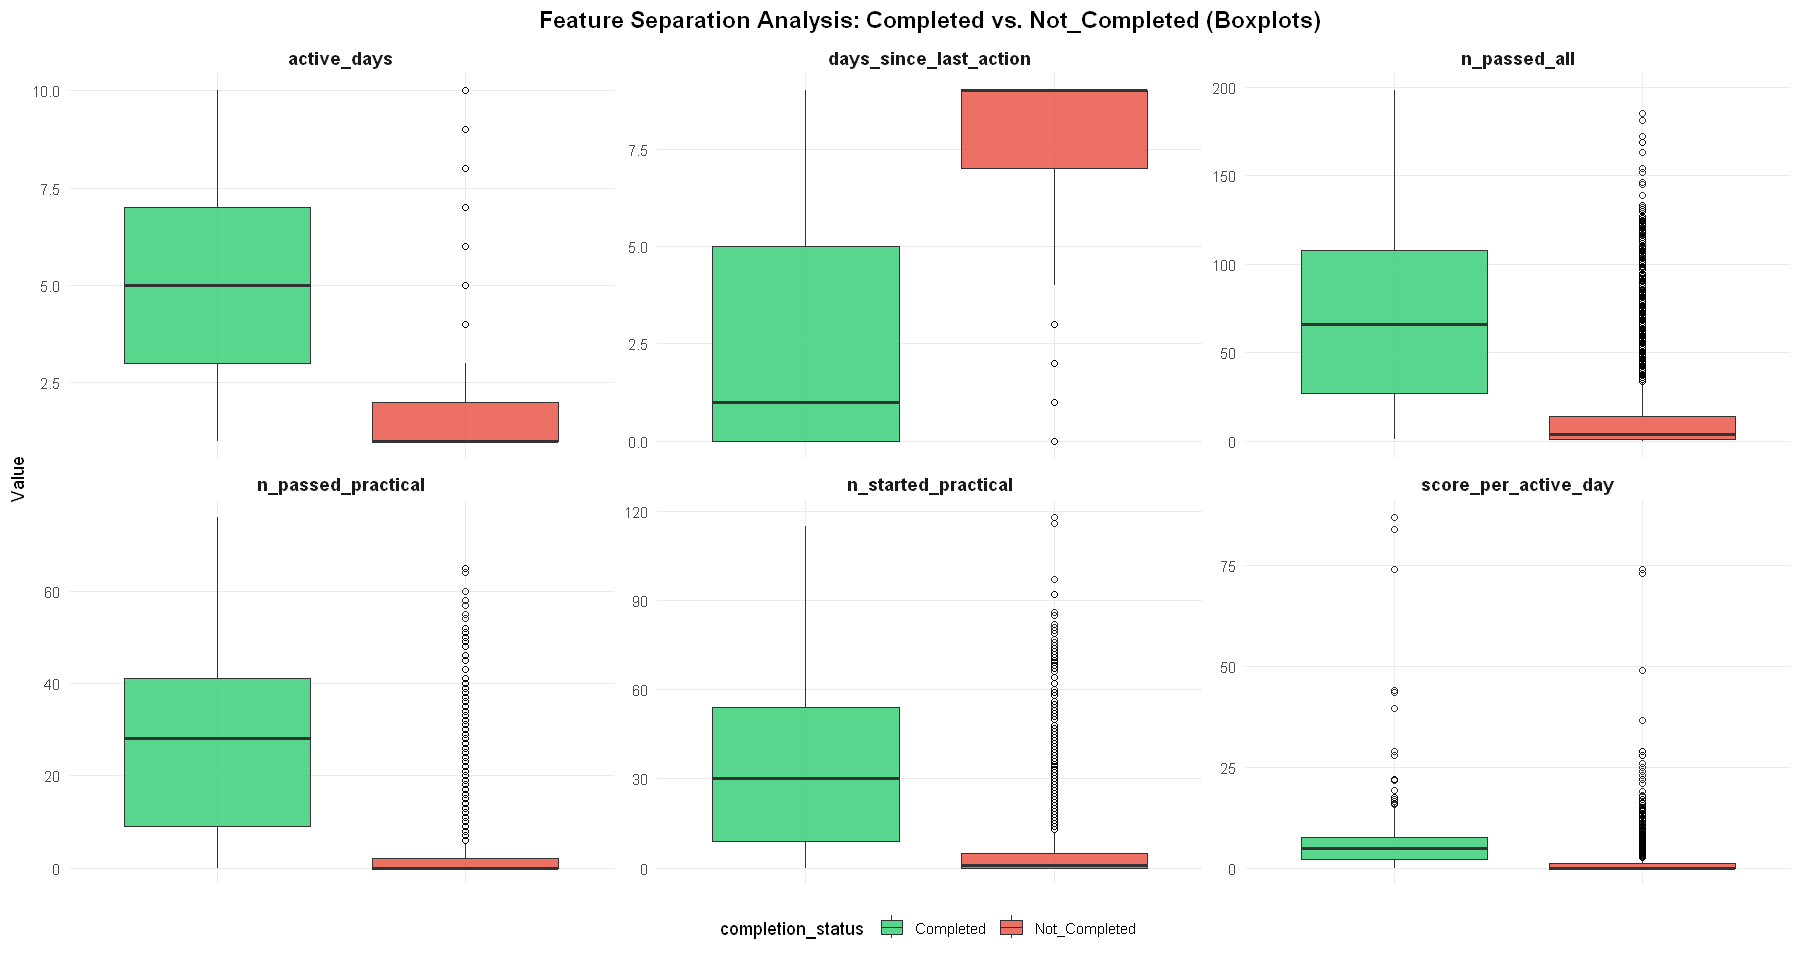

In [45]:
# Output size
options(repr.plot.width = 15, repr.plot.height = 8)

# Boxplot grid for class-wise feature comparison
ggplot(plot_data, aes(x = completion_status, y = value, fill = completion_status)) +
  geom_boxplot(alpha = 0.8, outlier.colour = "black", outlier.shape = 1) +
  facet_wrap(~ feature, scales = "free", ncol = 3) +
  scale_fill_manual(
    values = c("Completed" = "#2ecc71", "Not_Completed" = "#e74c3c"),
    labels = c("Completed", "Not_Completed")
  ) +
  theme_minimal() +
  labs(
    title = "Feature Separation Analysis: Completed vs. Not_Completed (Boxplots)",
    x = NULL,
    y = "Value"
  ) +
  theme(
    legend.position = "bottom",
    strip.text = element_text(face = "bold", size = 11),
    panel.grid.minor = element_blank(),
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    axis.text.x = element_blank()
  )

**Visual Interpretation: Feature Separation**

The boxplots confirm clear class-wise differences across the selected early behavioral features. Users who eventually `Completed` the course show substantially higher early activity, stronger practical engagement, and higher per-day productivity, while `Not_Completed` users remain concentrated near low or zero values for most activity and progress features.

The clearest visual separation appears in `n_passed_all`, `n_passed_practical`, `n_started_practical`, `score_per_active_day`, and `days_since_last_action`. For `days_since_last_action`, lower values indicate more recent activity, so the lower distribution for `Completed` users suggests that future completers remain active closer to the end of the 10-day observation window.

These plots are used as descriptive visual evidence, not as a formal feature-ranking method. They reinforce the conclusion that **early practical activation, sustained engagement, productivity, and recent activity** are among the strongest indicators of eventual course completion.


---

### Feature Correlation Review

> **Technical Note: Correlation Review**
>
> This block reviews pairwise correlations among training-set predictors before model training.
>
> The goal is diagnostic rather than automatic feature removal. Tree-based models can handle correlated predictors, but strong correlations are still useful for interpreting redundancy, feature importance, and progress-proxy behavior.

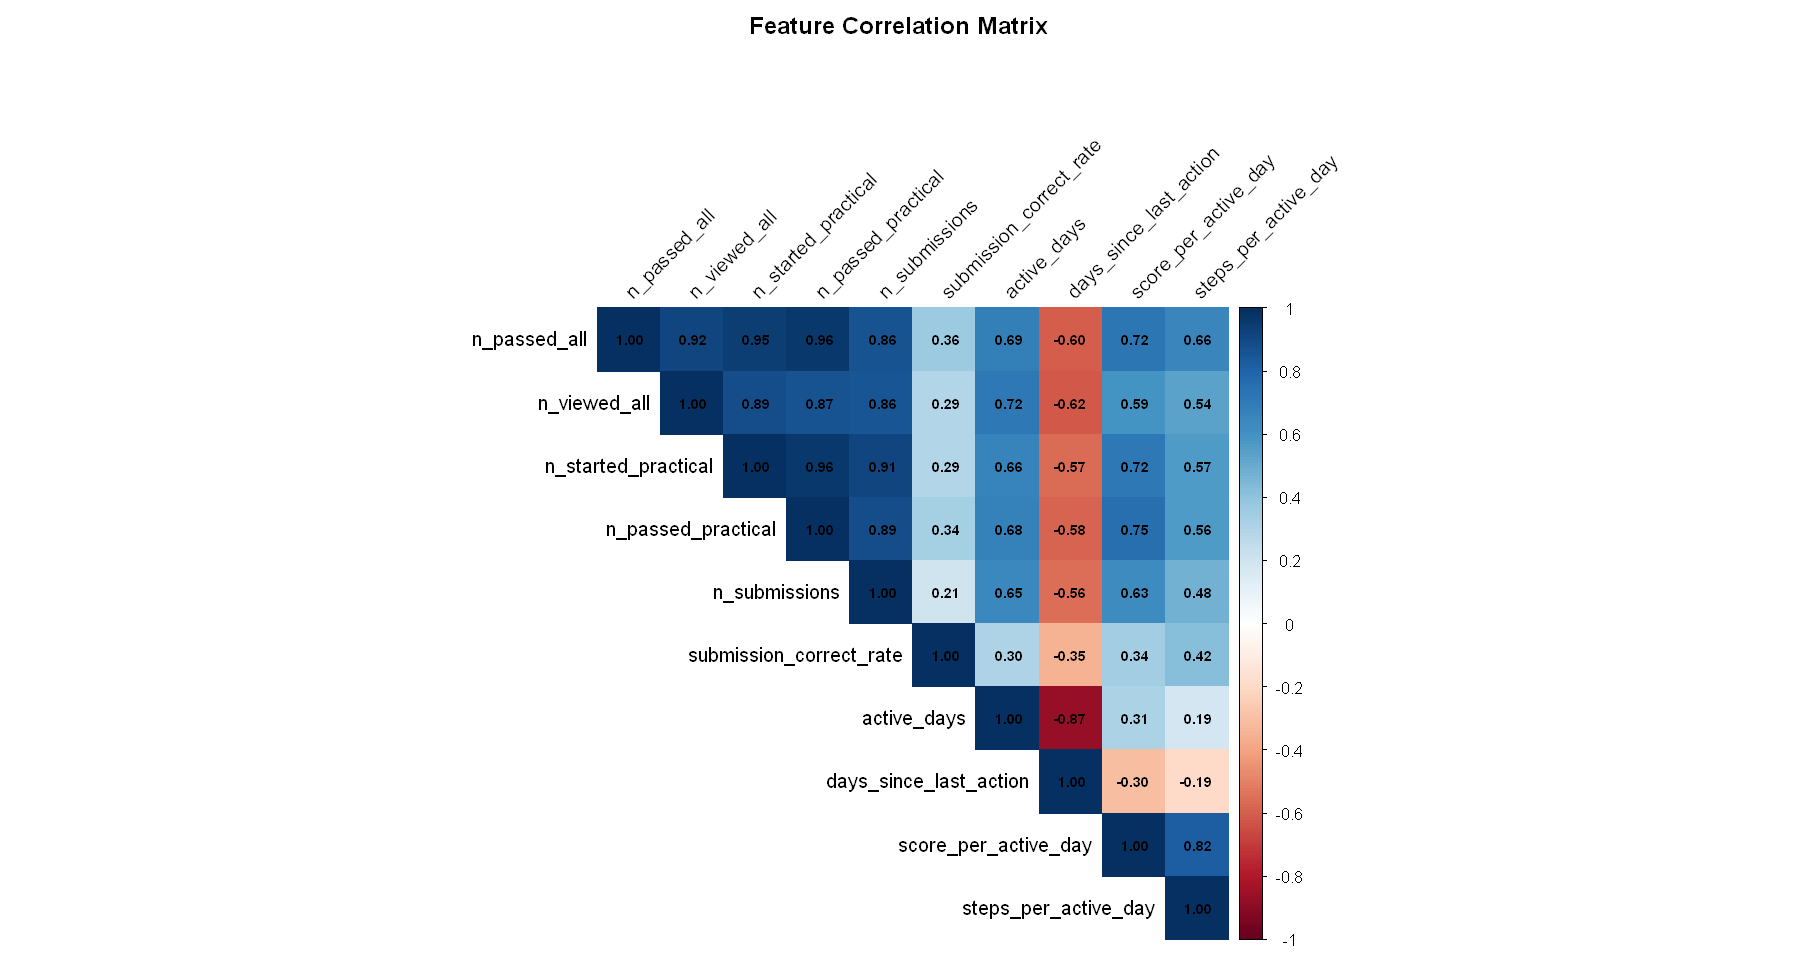

In [46]:
# Correlation matrix of training predictors
cor_matrix <- cor(train_data[, ..features], use = "complete.obs")

# Visualize correlation matrix once
corrplot(
  cor_matrix,
  method = "color",
  type = "upper",
  tl.col = "black",
  tl.srt = 45,
  addCoef.col = "black",
  number.cex = 0.7,
  title = "Feature Correlation Matrix",
  mar = c(0, 0, 2, 0)   # bottom, left, top, right
)

In [47]:
# Identify highly correlated feature pairs
high_cor_idx <- which(
  abs(cor_matrix) > 0.9 & upper.tri(cor_matrix),
  arr.ind = TRUE
)

# Convert highly correlated predictor pairs into a readable summary table
# for redundancy review before model training.
high_cor_pairs <- data.table(
  feature_1 = rownames(cor_matrix)[high_cor_idx[, 1]],
  feature_2 = colnames(cor_matrix)[high_cor_idx[, 2]],
  correlation = cor_matrix[high_cor_idx]
)

# Display highly correlated pairs
high_cor_pairs

feature_1,feature_2,correlation
<chr>,<chr>,<dbl>
n_passed_all,n_viewed_all,0.9154818
n_passed_all,n_started_practical,0.9496335
n_passed_all,n_passed_practical,0.9606567
n_started_practical,n_passed_practical,0.9649769
n_started_practical,n_submissions,0.9117228


**Interpretation: Feature Correlation Review**

The correlation matrix shows strong positive relationships among early activity and practical-engagement features. Five predictor pairs exceed the **0.90** threshold, with the strongest correlation observed between `n_started_practical` and `n_passed_practical` (`r` ≈ **0.965**).

A strong negative correlation between `active_days` and `days_since_last_action` is also behaviorally expected: users with more active days tend to remain active more recently, which results in lower recency-gap values.

Overall, the feature set contains meaningful dependence, but not enough redundancy to justify automatic feature removal before initial tree-based model training. These correlations are retained as useful context for interpreting feature importance and progress-proxy behavior.

---

**Training-Set EDA Summary: Progress-Aware Signals**

Across the training-set EDA, the same pattern emerges consistently within the **progress-aware feature space**: eventual completers show stronger early activity, greater practical engagement, higher productivity, and more recent activity.

The strongest early signals are concentrated in practical-progress and overall activity features. Because completion is score-based, pass-, score-, and success-related predictors should be interpreted as early progress signals aligned with the completion threshold, not as fully leakage-free independent predictors.

The correlation review does not justify automatic feature removal at this stage, so the full progress-aware predictor set is retained for baseline completion modeling.

The later leakage-reduced engagement-only robustness check evaluates whether meaningful predictive signal remains after removing direct score/progress proxy features.

---

## Shared Target Setup and Evaluation Helpers

> **Technical Note: Shared Evaluation Helpers**
>
> This section defines the common target setup and reusable evaluation functions used across all supervised model variants.
>
> `Completed` is treated as the positive class because it is the rare outcome. Therefore, threshold-based metrics, ROC-AUC, and PR-AUC are calculated for `Completed`.
>
> The helper functions cover threshold-based metrics, ROC-AUC and PR-AUC, validation-based threshold selection, final test evaluation, risk-ranking diagnostics using `Risk_Not_Completed = 1 - P(Completed)`, and probability calibration checks.
>
> Using the same helper functions across progress-aware, ablation, and engagement-only models keeps the evaluation logic consistent. The feature set changes across experiments, but the target definition and metric logic remain the same.

### Shared Target and Feature Setup

In [48]:
# Define the positive class used for model evaluation
positive_class <- "Completed"
target_levels <- c("Completed", "Not_Completed")

# Ensure consistent factor levels across all data splits
train_data[, completion_status := factor(as.character(completion_status), levels = target_levels)]
val_data[, completion_status := factor(as.character(completion_status), levels = target_levels)]
test_data[, completion_status := factor(as.character(completion_status), levels = target_levels)]

# Define predictor columns by excluding the target variable
features <- setdiff(names(train_data), "completion_status")

---

### Core Metric Helpers

In [49]:
# Replace missing metric values with 0
clean_na <- function(x) {
  ifelse(is.na(x), 0, x)
}

In [50]:
# Compute threshold-based classification metrics for a given probability cutoff
get_threshold_metrics <- function(probs,
                                  truth,
                                  threshold,
                                  positive_class = "Completed",
                                  target_levels = c("Completed", "Not_Completed")) {
  
  # Keep target levels consistent with the positive-class setup
  truth <- factor(as.character(truth), levels = target_levels)
  negative_class <- setdiff(levels(truth), positive_class)
  
  stopifnot(length(negative_class) == 1)
  
  # Convert predicted probabilities into class labels using the selected threshold
  preds <- factor(
    ifelse(probs >= threshold, positive_class, negative_class),
    levels = levels(truth)
  )
  
  # Build confusion matrix with `Completed` as the positive class
  conf <- caret::confusionMatrix(
    data = preds,
    reference = truth,
    positive = positive_class
  )
  
  # Extract the core metrics needed for F-scores and error-rate diagnostics
  recall <- clean_na(as.numeric(conf$byClass["Sensitivity"]))
  precision <- clean_na(as.numeric(conf$byClass["Pos Pred Value"]))
  specificity <- clean_na(as.numeric(conf$byClass["Specificity"]))
  
  # F1 balances precision and recall equally
  f1 <- ifelse(
    precision + recall == 0,
    0,
    2 * precision * recall / (precision + recall)
  )
  
  # F2 gives more weight to recall, which is useful under rare-class detection
  beta <- 2
  
  f2 <- ifelse(
    (beta^2 * precision + recall) == 0,
    0,
    (1 + beta^2) * precision * recall /
      ((beta^2 * precision) + recall)
  )
  
  # Return both positive-class metrics and error-rate diagnostics
  data.table(
    Threshold   = threshold,
    Recall      = recall,
    Precision   = precision,
    Specificity = specificity,
    F1          = f1,
    F2          = f2,
    FPR         = 1 - specificity,
    FNR         = 1 - recall
  )
}

In [51]:
# Compute threshold-independent ranking metrics
get_auc_metrics <- function(probs,
                            truth,
                            positive_class = "Completed") {
  
  # Convert the target into binary format required by ROC-AUC and PR-AUC
  y_true <- ifelse(truth == positive_class, 1, 0)
  
  # ROC-AUC evaluates overall ranking quality across all thresholds
  roc_auc <- as.numeric(
    pROC::roc(
      response = y_true,
      predictor = probs,
      quiet = TRUE
    )$auc
  )
  
  # PR-AUC is especially informative under strong class imbalance
  pr_auc <- MLmetrics::PRAUC(
    y_pred = probs,
    y_true = y_true
  )
  
  # Return rounded threshold-independent metrics
  data.table(
    ROC_AUC = round(roc_auc, 4),
    PR_AUC  = round(pr_auc, 4)
  )
}

---

### Validation and Final Test Evaluation Helpers

In [52]:
# Evaluate validation performance and select the best threshold
# according to the chosen optimization metric.
evaluate_validation_model <- function(probs_val,
                                      val_truth,
                                      optimize_metric = c("F1", "F2", "Recall", "Precision"),
                                      threshold_grid = seq(0.01, 0.99, by = 0.01),
                                      positive_class = "Completed") {
  
  optimize_metric <- match.arg(optimize_metric)
  
  y_true_val <- ifelse(val_truth == positive_class, 1, 0)
  
  # Compute validation ROC-AUC
  val_roc_auc <- as.numeric(
    pROC::roc(
      response = y_true_val,
      predictor = probs_val,
      quiet = TRUE
    )$auc
  )
  
  # Compute validation PR-AUC
  val_pr_auc <- MLmetrics::PRAUC(
    y_pred = probs_val,
    y_true = y_true_val
  )
  
  # Evaluate all candidate thresholds
  val_threshold_metrics <- rbindlist(lapply(threshold_grid, function(t) {
    get_threshold_metrics(
      probs = probs_val,
      truth = val_truth,
      threshold = t,
      positive_class = positive_class
    )
  }))
  
  # Select the threshold with the best target metric
  val_threshold_metrics <- val_threshold_metrics[
    order(-val_threshold_metrics[[optimize_metric]], Threshold)
  ]
  
  best_row <- val_threshold_metrics[1]
  
  # Return compact validation summary
  data.table(
    Optimize_By = optimize_metric,
    Val_Threshold = best_row$Threshold,
    Val_ROC_AUC = round(val_roc_auc, 4),
    Val_PR_AUC = round(val_pr_auc, 4),
    Val_Best_Metric = round(best_row[[optimize_metric]], 4),
    Val_Recall = round(best_row$Recall, 3),
    Val_Precision = round(best_row$Precision, 3),
    Val_F1 = round(best_row$F1, 3),
    Val_F2 = round(best_row$F2, 3),
    Val_Specificity = round(best_row$Specificity, 3),
    Val_FPR = round(best_row$FPR, 3),
    Val_FNR = round(best_row$FNR, 3)
  )
}

In [53]:
# Evaluate final test performance using a fixed validation-selected threshold.
evaluate_final_test_model <- function(probs_test,
                                      test_truth,
                                      threshold,
                                      positive_class = "Completed") {
  
  # Compute threshold-based test metrics
  test_threshold_metrics <- get_threshold_metrics(
    probs = probs_test,
    truth = test_truth,
    threshold = threshold,
    positive_class = positive_class
  )
  
  # Compute threshold-independent test metrics
  test_auc_metrics <- get_auc_metrics(
    probs = probs_test,
    truth = test_truth,
    positive_class = positive_class
  )
  
  # Return compact final test summary
  data.table(
    Threshold = threshold,
    Test_ROC_AUC = test_auc_metrics$ROC_AUC,
    Test_PR_AUC = test_auc_metrics$PR_AUC,
    Test_Recall = round(test_threshold_metrics$Recall, 3),
    Test_Precision = round(test_threshold_metrics$Precision, 3),
    Test_F1 = round(test_threshold_metrics$F1, 3),
    Test_F2 = round(test_threshold_metrics$F2, 3),
    Test_Specificity = round(test_threshold_metrics$Specificity, 3),
    Test_FPR = round(test_threshold_metrics$FPR, 3),
    Test_FNR = round(test_threshold_metrics$FNR, 3)
  )
}

---

### Risk and Completion Ranking Policy Helpers

In [54]:
# Build high-risk prioritization table using predicted P(Completed)
get_risk_policy_table <- function(model_id,
                                  probs_completed,
                                  truth,
                                  policy_shares = c(0.05, 0.10, 0.20, 0.30),
                                  positive_class = "Completed") {
  
  # Convert completion probability into non-completion risk score
  policy_data <- data.table(
    P_Completed = probs_completed,
    Risk_Not_Completed = 1 - probs_completed,
    Actual_Completed = as.integer(truth == positive_class),
    Actual_Not_Completed = as.integer(truth != positive_class)
  )
  
  # Baseline rates are used as reference points for targeted risk groups
  baseline_completion_rate <- mean(policy_data$Actual_Completed)
  baseline_non_completion_rate <- mean(policy_data$Actual_Not_Completed)
  
  n_total <- nrow(policy_data)
  
  policy_results <- rbindlist(lapply(policy_shares, function(share) {
    
    # Select the top X% users with the highest estimated non-completion risk
    n_target <- ceiling(n_total * share)
    
    targeted_users <- policy_data[
      order(-Risk_Not_Completed)
    ][1:n_target]
    
    completion_rate <- mean(targeted_users$Actual_Completed)
    non_completion_rate <- mean(targeted_users$Actual_Not_Completed)
    
    # Summarize how concentrated non-completion is within the targeted group
    data.table(
      Model_ID = model_id,
      Policy = paste0("Top ", share * 100, "% highest risk"),
      Users = n_target,
      Completion_Rate = round(completion_rate, 4),
      Baseline_Completion_Rate = round(baseline_completion_rate, 4),
      Completion_Reduction = round(baseline_completion_rate - completion_rate, 4),
      Non_Completion_Rate = round(non_completion_rate, 4),
      Baseline_Non_Completion_Rate = round(baseline_non_completion_rate, 4),
      Non_Completion_Lift = round(non_completion_rate / baseline_non_completion_rate, 3),
      Completed_Users = sum(targeted_users$Actual_Completed),
      Not_Completed_Users = sum(targeted_users$Actual_Not_Completed)
    )
  }))
  
  return(policy_results)
}

In [55]:
# Build complementary diagnostic for users with the strongest completion signal
get_completion_priority_table <- function(model_id,
                                          probs_completed,
                                          truth,
                                          policy_shares = c(0.05, 0.10, 0.20, 0.30),
                                          positive_class = "Completed") {
  
  policy_data <- data.table(
    P_Completed = probs_completed,
    Risk_Not_Completed = 1 - probs_completed,
    Actual_Completed = as.integer(truth == positive_class),
    Actual_Not_Completed = as.integer(truth != positive_class)
  )
  
  # Baseline completion rate is used to calculate completion lift
  baseline_completion_rate <- mean(policy_data$Actual_Completed)
  n_total <- nrow(policy_data)
  
  completion_priority_results <- rbindlist(lapply(policy_shares, function(share) {
    
    # Select the top X% users with the highest predicted completion probability
    n_segment <- ceiling(n_total * share)
    
    high_completion_users <- policy_data[
      order(-P_Completed)
    ][1:n_segment]
    
    # Compare completion concentration in the selected segment against baseline
    data.table(
      Model_ID = model_id,
      Segment = paste0("Top ", share * 100, "% highest P(Completed)"),
      Users = n_segment,
      Completion_Rate = round(mean(high_completion_users$Actual_Completed), 4),
      Baseline_Completion_Rate = round(baseline_completion_rate, 4),
      Completion_Lift = round(
        mean(high_completion_users$Actual_Completed) / baseline_completion_rate,
        3
      )
    )
  }))
  
  return(completion_priority_results)
}

---

### Calibration Helpers

In [56]:
# Build calibration table by comparing predicted P(Completed)
# with the observed completion rate within probability bins
get_calibration_table <- function(model_id,
                                  probs_completed,
                                  truth,
                                  positive_class = "Completed",
                                  breaks = c(0, 0.01, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00)) {
  
  calibration_data <- data.table(
    Model_ID = model_id,
    P_Completed = probs_completed,
    Actual_Completed = as.integer(truth == positive_class)
  )
  
  # Group predicted probabilities into predefined probability intervals
  calibration_data[, Probability_Bin := cut(
    P_Completed,
    breaks = breaks,
    include.lowest = TRUE,
    right = TRUE
  )]
  
  # Compare mean predicted probability with the actual completion rate per bin
  calibration_table <- calibration_data[, .(
    Users = .N,
    Mean_P_Completed = round(mean(P_Completed), 4),
    Actual_Completion_Rate = round(mean(Actual_Completed), 4),
    Calibration_Gap = round(mean(P_Completed) - mean(Actual_Completed), 4)
  ), by = .(Model_ID, Probability_Bin)]
  
  calibration_table <- calibration_table[
    order(Model_ID, Probability_Bin)
  ]
  
  return(calibration_table)
}

In [57]:
# Compute Brier Score as a calibration-quality metric.
# Lower values indicate better agreement between predicted probabilities
# and the actual binary completion outcome.
get_brier_score <- function(model_id,
                            probs_completed,
                            truth,
                            positive_class = "Completed") {
  
  actual_completed <- as.integer(truth == positive_class)
  
  data.table(
    Model_ID = model_id,
    Brier_Score = round(mean((probs_completed - actual_completed)^2), 5),
    Mean_P_Completed = round(mean(probs_completed), 4),
    Actual_Completion_Rate = round(mean(actual_completed), 4)
  )
}

---

##  Reusable Model Training Functions

> **Technical Note: Reusable Model Training Logic**
>
> This block defines reusable wrappers for training and validating Random Forest and XGBoost models.
>
> The same functions are reused across feature sets to keep model comparison consistent. The implemented strategies include baseline models, class weighting, 1:3 resampling, and 1:1 resampling.

### Random Forest Training Wrapper

In [58]:
# Train one Random Forest strategy and evaluate it on the validation set
train_evaluate_rf_validation <- function(strategy_id,
                                         train_input,
                                         val_input,
                                         feature_cols,
                                         feature_set_name,
                                         classwt = NULL,
                                         sampsize = NULL,
                                         optimize_metric = "F2") {
  
  set.seed(42)
  
  # Base Random Forest configuration shared by all RF strategies
  rf_args <- list(
    x = train_input[, ..feature_cols],
    y = train_input$completion_status,
    ntree = 500,
    mtry = floor(sqrt(length(feature_cols))),
    importance = TRUE
  )
  
  # Optional class weighting for imbalance-aware RF models
  if (!is.null(classwt)) {
    rf_args$classwt <- classwt
  }
  
  # Optional stratified sampling for resampled RF models
  if (!is.null(sampsize)) {
    rf_args$strata <- train_input$completion_status
    rf_args$sampsize <- sampsize
  }
  
  # Train RF using the selected strategy-specific arguments
  rf_fit <- do.call(randomForest::randomForest, rf_args)
  
  # Predict validation probabilities for the positive class
  rf_probs_val <- predict(
    rf_fit,
    newdata = val_input[, ..feature_cols],
    type = "prob"
  )[, positive_class]
  
  # Evaluate validation performance and select the best threshold
  rf_result <- evaluate_validation_model(
    probs_val = rf_probs_val,
    val_truth = val_input$completion_status,
    optimize_metric = optimize_metric,
    positive_class = positive_class
  )
  
  # Add metadata for later comparison across feature sets and strategies
  rf_result[, `:=`(
    Feature_Set = feature_set_name,
    Model_ID = strategy_id
  )]
  
  return(list(
    model = rf_fit,
    result = rf_result
  ))
}

---

### XGBoost: Data Preparation Helpers & Training Wrapper

In [59]:
# Binary target label for XGBoost: Completed = 1, otherwise = 0
make_xgb_label_validation <- function(data) {
  ifelse(data$completion_status == positive_class, 1, 0)
}

In [60]:
# XGBoost helper: converts a data.table into DMatrix format with binary labels
make_xgb_dmatrix_generic <- function(data, feature_cols) {
  
  # Convert selected predictors into the numeric matrix required by XGBoost
  x <- data.matrix(data[, ..feature_cols])
  
  # Create binary target label: Completed = 1, otherwise = 0
  y <- make_xgb_label_validation(data)
  
  xgboost::xgb.DMatrix(
    data = x,
    label = y
  )
}

In [61]:
# XGBoost helper: creates a downsampled training set with a fixed negative-to-positive ratio
make_xgb_resampled_train_generic <- function(train_input,
                                             negative_to_positive_ratio = 3) {
  
  set.seed(42)
  
  # Keep all positive cases and sample only from the majority class
  positive_idx <- which(train_input$completion_status == positive_class)
  negative_idx <- which(train_input$completion_status != positive_class)
  
  n_positive <- length(positive_idx)
  
  # Limit the number of negative cases according to the requested ratio
  n_negative_sample <- min(
    length(negative_idx),
    negative_to_positive_ratio * n_positive
  )
  
  sampled_negative_idx <- sample(
    negative_idx,
    size = n_negative_sample,
    replace = FALSE
  )
  
  # Combine positives with sampled negatives and shuffle row order
  sampled_idx <- sample(c(positive_idx, sampled_negative_idx))
  
  train_input[sampled_idx]
}

In [62]:
# XGBoost helper: train one validation-stage XGBoost strategy and return the model plus metrics
train_evaluate_xgb_validation <- function(strategy_id,
                                          train_input,
                                          val_input,
                                          feature_cols,
                                          feature_set_name,
                                          scale_pos_weight = NULL,
                                          optimize_metric = "F2") {
  
  # Convert train and validation sets to XGBoost's DMatrix format
  dtrain <- make_xgb_dmatrix_generic(train_input, feature_cols)
  dval   <- make_xgb_dmatrix_generic(val_input, feature_cols)
  
  # Shared baseline XGBoost configuration for comparable model strategies
  xgb_params <- list(
    objective = "binary:logistic",
    eval_metric = "aucpr",
    eta = 0.05,
    max_depth = 4,
    min_child_weight = 1,
    subsample = 0.8,
    colsample_bytree = 0.8,
    nthread = 1
  )
  
  # Optional class weighting for imbalance-aware XGBoost variants
  if (!is.null(scale_pos_weight)) {
    xgb_params$scale_pos_weight <- scale_pos_weight
  }
  
  set.seed(42)
  
  # Train model with validation monitoring and early stopping
  xgb_fit <- xgboost::xgb.train(
    params = xgb_params,
    data = dtrain,
    nrounds = 500,
    watchlist = list(train = dtrain, val = dval),
    early_stopping_rounds = 30,
    maximize = TRUE,
    verbose = 0
  )
  
  # Predict validation probabilities for the positive class
  xgb_probs_val <- predict(xgb_fit, dval)
  
  # Evaluate validation metrics and select the best threshold
  xgb_result <- evaluate_validation_model(
    probs_val = xgb_probs_val,
    val_truth = val_input$completion_status,
    optimize_metric = optimize_metric,
    positive_class = positive_class
  )
  
  # Attach metadata for later comparison across strategies and feature sets
  xgb_result[, `:=`(
    Feature_Set = feature_set_name,
    Model_ID = strategy_id
  )]
  
  return(list(
    model = xgb_fit,
    result = xgb_result
  ))
}

---

### Baseline Strategy Runner

In [63]:
# Run all baseline RF and XGBoost strategies on one feature set
run_all_model_strategies_validation <- function(train_input,
                                                val_input,
                                                feature_cols,
                                                feature_set_name,
                                                optimize_metric = "F2") {
  
  # Containers for trained model objects and validation result tables
  models <- list()
  results <- list()
  
  # ============================================================
  # Random Forest imbalance setup
  # ============================================================
  
  # Count target classes to derive class weights and sampling sizes
  rf_class_counts <- table(train_input$completion_status)
  
  negative_class <- setdiff(
    levels(train_input$completion_status),
    positive_class
  )
  
  stopifnot(length(negative_class) == 1)
  
  n_pos <- as.integer(rf_class_counts[positive_class])
  n_neg <- as.integer(rf_class_counts[negative_class])
  
  # Inverse-frequency class weights for weighted RF
  rf_class_weights <- sum(rf_class_counts) /
    (length(rf_class_counts) * rf_class_counts)
  
  rf_class_weights <- as.numeric(rf_class_weights)
  names(rf_class_weights) <- names(rf_class_counts)
  
  # Stratified RF sampling: keep all Completed users and sample negatives at 1:3
  rf_sampsize_1_3 <- setNames(
    integer(length(levels(train_input$completion_status))),
    levels(train_input$completion_status)
  )
  
  rf_sampsize_1_3[positive_class] <- n_pos
  rf_sampsize_1_3[negative_class] <- min(n_neg, 3 * n_pos)
  
  # Stratified RF sampling: keep all Completed users and sample negatives at 1:1
  rf_sampsize_1_1 <- setNames(
    integer(length(levels(train_input$completion_status))),
    levels(train_input$completion_status)
  )
  
  rf_sampsize_1_1[positive_class] <- n_pos
  rf_sampsize_1_1[negative_class] <- min(n_neg, n_pos)
  
  
  # ============================================================
  # Random Forest strategy comparison
  # ============================================================
  
  # Baseline RF without explicit imbalance handling
  rf_baseline <- train_evaluate_rf_validation(
    strategy_id = "RF_Baseline",
    train_input = train_input,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    optimize_metric = optimize_metric
  )
  
  models[["RF_Baseline"]] <- rf_baseline$model
  results[["RF_Baseline"]] <- rf_baseline$result
  
  
  # Weighted RF using inverse-frequency class weights
  rf_weighted <- train_evaluate_rf_validation(
    strategy_id = "RF_Weighted",
    train_input = train_input,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    classwt = rf_class_weights,
    optimize_metric = optimize_metric
  )
  
  models[["RF_Weighted"]] <- rf_weighted$model
  results[["RF_Weighted"]] <- rf_weighted$result
  
  
  # RF with moderate negative-class downsampling
  rf_resampled_1_3 <- train_evaluate_rf_validation(
    strategy_id = "RF_Resampled_1_3",
    train_input = train_input,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    sampsize = rf_sampsize_1_3,
    optimize_metric = optimize_metric
  )
  
  models[["RF_Resampled_1_3"]] <- rf_resampled_1_3$model
  results[["RF_Resampled_1_3"]] <- rf_resampled_1_3$result
  
  
  # RF with balanced 1:1 class sampling
  rf_resampled_1_1 <- train_evaluate_rf_validation(
    strategy_id = "RF_Resampled_1_1",
    train_input = train_input,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    sampsize = rf_sampsize_1_1,
    optimize_metric = optimize_metric
  )
  
  models[["RF_Resampled_1_1"]] <- rf_resampled_1_1$model
  results[["RF_Resampled_1_1"]] <- rf_resampled_1_1$result
  
  
  # ============================================================
  # XGBoost imbalance setup
  # ============================================================
  
  # Convert target to binary labels for XGBoost-specific imbalance handling
  y_train <- make_xgb_label_validation(train_input)
  
  xgb_n_pos <- sum(y_train == 1)
  xgb_n_neg <- sum(y_train == 0)
  
  # Class weight for weighted XGBoost
  xgb_scale_pos_weight <- xgb_n_neg / xgb_n_pos
  
  # Resampled XGBoost training sets with different negative-to-positive ratios
  xgb_train_1_3 <- make_xgb_resampled_train_generic(
    train_input = train_input,
    negative_to_positive_ratio = 3
  )
  
  xgb_train_1_1 <- make_xgb_resampled_train_generic(
    train_input = train_input,
    negative_to_positive_ratio = 1
  )
  
  
  # ============================================================
  # XGBoost strategy comparison
  # ============================================================
  
  # Baseline XGBoost without explicit imbalance handling
  xgb_baseline <- train_evaluate_xgb_validation(
    strategy_id = "XGB_Baseline",
    train_input = train_input,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    scale_pos_weight = NULL,
    optimize_metric = optimize_metric
  )
  
  models[["XGB_Baseline"]] <- xgb_baseline$model
  results[["XGB_Baseline"]] <- xgb_baseline$result
  
  
  # Weighted XGBoost using scale_pos_weight
  xgb_weighted <- train_evaluate_xgb_validation(
    strategy_id = "XGB_Weighted",
    train_input = train_input,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    scale_pos_weight = xgb_scale_pos_weight,
    optimize_metric = optimize_metric
  )
  
  models[["XGB_Weighted"]] <- xgb_weighted$model
  results[["XGB_Weighted"]] <- xgb_weighted$result
  
  
  # XGBoost trained on a 1:3 resampled training set
  xgb_resampled_1_3 <- train_evaluate_xgb_validation(
    strategy_id = "XGB_Resampled_1_3",
    train_input = xgb_train_1_3,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    scale_pos_weight = NULL,
    optimize_metric = optimize_metric
  )
  
  models[["XGB_Resampled_1_3"]] <- xgb_resampled_1_3$model
  results[["XGB_Resampled_1_3"]] <- xgb_resampled_1_3$result
  
  
  # XGBoost trained on a balanced 1:1 resampled training set
  xgb_resampled_1_1 <- train_evaluate_xgb_validation(
    strategy_id = "XGB_Resampled_1_1",
    train_input = xgb_train_1_1,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    scale_pos_weight = NULL,
    optimize_metric = optimize_metric
  )
  
  models[["XGB_Resampled_1_1"]] <- xgb_resampled_1_1$model
  results[["XGB_Resampled_1_1"]] <- xgb_resampled_1_1$result
  
  
  # ============================================================
  # Aggregate validation results
  # ============================================================
  
  # Combine all validation result rows into one comparison table
  results_table <- rbindlist(
    results,
    use.names = TRUE,
    fill = TRUE
  )
  
  # Standardize column order for compact reporting
  setcolorder(
    results_table,
    c(
      "Feature_Set",
      "Model_ID",
      "Optimize_By",
      "Val_Threshold",
      "Val_Best_Metric",
      "Val_ROC_AUC",
      "Val_PR_AUC",
      "Val_Recall",
      "Val_Precision",
      "Val_F1",
      "Val_F2",
      "Val_Specificity",
      "Val_FPR",
      "Val_FNR"
    )
  )
  
  # Sort by the main threshold-oriented metric, then by ranking quality
  results_table <- results_table[order(-Val_F2, -Val_PR_AUC)]
  
  return(list(
    models = models,
    results = results_table
  ))
}

---

## Baseline Results Aggregation

### Progress-Aware Baseline Model Training on Original Features

> **Technical Note: Original Feature Baseline**
>
> This baseline uses the full original 10-day feature set, including early progress and score-related variables. Therefore, it represents the **progress-aware prediction setting**.

In [64]:
# Run baseline model comparison on the original progress-aware feature set
original_comparison <- run_all_model_strategies_validation(
  train_input = train_data,
  val_input = val_data,
  feature_cols = features,
  feature_set_name = "Original",
  optimize_metric = "F2"
)

# Store trained baseline models for later inspection or comparison
models_original <- original_comparison$models

# Store validation results from the original-feature baseline comparison
baseline_results_validation <- original_comparison$results

In [65]:
# Create a compact validation summary for reporting
baseline_results_compact <- baseline_results_validation[
  ,
  .(
    Model_ID,
    Threshold = Val_Threshold,
    ROC_AUC   = Val_ROC_AUC,
    PR_AUC    = Val_PR_AUC,
    Recall    = Val_Recall,
    Precision = Val_Precision,
    F2        = Val_F2,
    FPR       = Val_FPR
  )
]

# Display compact baseline comparison table
baseline_results_compact

Model_ID,Threshold,ROC_AUC,PR_AUC,Recall,Precision,F2,FPR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
XGB_Weighted,0.66,0.9111,0.6039,0.747,0.439,0.655,0.067
XGB_Resampled_1_3,0.46,0.9107,0.6052,0.700,0.475,0.639,0.055
XGB_Baseline,0.32,0.9072,0.6094,0.704,0.454,0.634,0.060
XGB_Resampled_1_1,0.70,0.9036,0.5904,0.708,0.445,0.633,0.062
RF_Resampled_1_1,0.63,0.8973,0.5754,0.691,0.425,0.614,0.066
RF_Resampled_1_3,0.37,0.8929,0.5832,0.700,0.400,0.609,0.074
RF_Baseline,0.17,0.8818,0.5726,0.682,0.415,0.605,0.068
RF_Weighted,0.05,0.5738,0.0828,0.901,0.089,0.319,0.651


**Result Summary: Progress-Aware Baseline Models**

This baseline comparison belongs to the **progress-aware prediction setting**. It uses the original 10-day feature set, including early activity, practical engagement, progress, submission, productivity, and recency variables.

The models predict `P(Completed)` with `Completed` treated as the positive class. For business use, this score is later inverted into:

`Risk_Not_Completed = 1 - P(Completed)`

Therefore, validation F2 and Recall measure completion-signal detection, while later retention analysis focuses on users at the opposite end of the probability distribution: those with the lowest `P(Completed)`.

At this stage, no final model is selected. The table is used as a validation-development diagnostic before feature engineering and targeted tuning.

| Baseline role | Model_ID | Interpretation |
|---|---|---|
| Strongest threshold-based baseline | `XGB_Weighted` | Highest baseline F2, but requires comparison after feature engineering and tuning. |
| Strongest ranking baseline | `XGB_Baseline` | Highest baseline PR-AUC and strongest initial candidate for probability-based ranking. |
| Random Forest challengers | `RF_Resampled_1_1` / `RF_Resampled_1_3` | Useful intervention-oriented alternatives for later comparison. |
| Weak baseline candidate | `RF_Weighted` | Not competitive due to very low PR-AUC and very high FPR. |

**Modeling Implication**

The original progress-aware feature set already contains strong predictive signal. However, these results are not used for final model selection. All model variants are re-evaluated after feature engineering, and final decisions are made only after targeted tuning and validation-based model selection.

---

## Feature Engineering

> **Technical Note: Progress-Aware Feature Engineering**
>
> Feature engineering enriches the original 10-day feature set with interpretable activation, ratio/intensity, practice, and recency signals linked to the Activation Gap.
>
> This step belongs to the **progress-aware prediction setting**: all features are calculated within the first 10 days, but some pass-, submission-, success-, and productivity-related variables may still act as progress-based target proxies because completion is score-based.
>
> Direct score/progress proxy features are later removed in the leakage-reduced engagement-only robustness check.

### Create and Apply Engineered Features

In [66]:
# Add engineered activation, ratio, and intensity features
add_engineered_features <- function(data) {
  
  data_engineered <- copy(data)
  
  # Binary activation flags
  data_engineered[, has_started_practical := as.integer(n_started_practical > 0)]
  data_engineered[, has_submitted := as.integer(n_submissions > 0)]
  data_engineered[, has_passed_practical := as.integer(n_passed_practical > 0)]
  data_engineered[, is_recently_active := as.integer(days_since_last_action <= 2)]
  
  # Practical activation intensity relative to viewed steps
  data_engineered[, started_practical_per_viewed_step := fifelse(
    n_viewed_all > 0,
    n_started_practical / n_viewed_all,
    0
  )]
  
  # Practical success rate among started practical steps
  data_engineered[, practical_pass_rate := fifelse(
    n_started_practical > 0,
    n_passed_practical / n_started_practical,
    0
  )]
  
  # Submission intensity per started practical step
  data_engineered[, submissions_per_started_practical := fifelse(
    n_started_practical > 0,
    n_submissions / n_started_practical,
    0
  )]
  
  # Overall progress intensity relative to viewed steps
  data_engineered[, passed_per_viewed_step := fifelse(
    n_viewed_all > 0,
    n_passed_all / n_viewed_all,
    0
  )]
  
  # Submission and practical-start intensity per active day
  data_engineered[, submissions_per_active_day := fifelse(
    active_days > 0,
    n_submissions / active_days,
    0
  )]
  
  data_engineered[, practical_starts_per_active_day := fifelse(
    active_days > 0,
    n_started_practical / active_days,
    0
  )]
  
  return(data_engineered)
}

In [67]:
# Apply the same feature-engineering logic to train and validation sets
train_data_engineered <- add_engineered_features(train_data)
val_data_engineered   <- add_engineered_features(val_data)

In [68]:
# Define engineered feature set
features_engineered <- setdiff(
  names(train_data_engineered),
  "completion_status"
)

# Identify newly created features only
engineered_cols <- setdiff(features_engineered, features)

engineered_cols

[1] "has_started_practical"             "has_submitted"                    
 [3] "has_passed_practical"              "is_recently_active"               
 [5] "started_practical_per_viewed_step" "practical_pass_rate"              
 [7] "submissions_per_started_practical" "passed_per_viewed_step"           
 [9] "submissions_per_active_day"        "practical_starts_per_active_day"

---

## Engineered Feature Validation and Summary

In [69]:
# Verify that train and validation have the same engineered predictor columns
stopifnot(identical(
  sort(features_engineered),
  sort(setdiff(names(val_data_engineered), "completion_status"))
))

In [70]:
# Check dimensions
dim(train_data_engineered)
dim(val_data_engineered)

[1] 10595    21

[1] 3531   21

In [71]:
# Verification:

# Check missing values
stopifnot(any(is.na(train_data_engineered)) == FALSE)
stopifnot(any(is.na(val_data_engineered)) == FALSE)


# Check infinite values in predictors
stopifnot(any(!is.finite(as.matrix(train_data_engineered[, ..features_engineered]))) == FALSE)
stopifnot(any(!is.finite(as.matrix(val_data_engineered[, ..features_engineered]))) == FALSE)


# Target must still be present
stopifnot("completion_status" %in% names(train_data_engineered))
stopifnot("completion_status" %in% names(val_data_engineered))


# Target must not be included in predictors
stopifnot(!"completion_status" %in% features_engineered)

**Progress-Aware Engineered Feature Groups**

| Feature group | New features | Business meaning |
|---|---|---|
| Activation flags | `has_started_practical`, `has_submitted`, `has_passed_practical`, `is_recently_active` | Captures whether the user crossed key activation thresholds during the first 10 days. |
| Behavioral ratios / relative intensity indicators | `started_practical_per_viewed_step`, `practical_pass_rate`, `submissions_per_started_practical`, `passed_per_viewed_step` | Measures practical engagement, progress intensity, and practical success behavior. Ratios based on viewed counts are interpreted as relative intensity indicators rather than strict bounded conversion rates, because viewed, started, and passed events are not always perfectly nested in the platform logs. |
| Practice intensity | `submissions_per_active_day`, `practical_starts_per_active_day` | Distinguishes users who are merely active from users who actively practice. |

In [72]:
# Review summary of engineered features
summary(train_data_engineered[, ..engineered_cols])

 has_started_practical has_submitted    has_passed_practical is_recently_active
 Min.   :0.0000        Min.   :0.0000   Min.   :0.0000       Min.   :0.0000    
 1st Qu.:0.0000        1st Qu.:0.0000   1st Qu.:0.0000       1st Qu.:0.0000    
 Median :1.0000        Median :0.0000   Median :0.0000       Median :0.0000    
 Mean   :0.5405        Mean   :0.4636   Mean   :0.4564       Mean   :0.1684    
 3rd Qu.:1.0000        3rd Qu.:1.0000   3rd Qu.:1.0000       3rd Qu.:0.0000    
 Max.   :1.0000        Max.   :1.0000   Max.   :1.0000       Max.   :1.0000    
 started_practical_per_viewed_step practical_pass_rate
 Min.   :0.00000                   Min.   :0.0000     
 1st Qu.:0.00000                   1st Qu.:0.0000     
 Median :0.09565                   Median :0.0000     
 Mean   :0.15436                   Mean   :0.3744     
 3rd Qu.:0.24000                   3rd Qu.:0.8824     
 Max.   :3.00000                   Max.   :1.0000     
 submissions_per_started_practical passed_per_viewed_st

---

### Class-Wise Review of Engineered Features

In [73]:
# Compare engineered features between Completed and Not_Completed users
engineered_feature_compare <- rbindlist(lapply(engineered_cols, function(col) {
  
  # Split feature values by completion outcome
  nc_vals <- train_data_engineered[completion_status == "Not_Completed"][[col]]
  c_vals  <- train_data_engineered[completion_status == "Completed"][[col]]
  
  data.table(
    feature = col,
    
    # Robust central tendency comparison
    not_completed_median = round(median(nc_vals, na.rm = TRUE), 3),
    completed_median = round(median(c_vals, na.rm = TRUE), 3),
    median_diff = round(
      median(c_vals, na.rm = TRUE) - median(nc_vals, na.rm = TRUE),
      3
    ),
    
    # Mean comparison as a complementary signal
    not_completed_mean = round(mean(nc_vals, na.rm = TRUE), 3),
    completed_mean = round(mean(c_vals, na.rm = TRUE), 3),
    mean_diff = round(
      mean(c_vals, na.rm = TRUE) - mean(nc_vals, na.rm = TRUE),
      3
    )
  )
}))

# Rank engineered features by the strongest class-wise separation
engineered_feature_compare <- engineered_feature_compare[
  order(-abs(median_diff), -abs(mean_diff))
]

engineered_feature_compare

feature,not_completed_median,completed_median,median_diff,not_completed_mean,completed_mean,mean_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
submissions_per_active_day,0.000,8.400,8.400,2.513,9.977,7.464
practical_starts_per_active_day,0.500,5.600,5.100,1.855,6.715,4.860
submissions_per_started_practical,0.000,1.319,1.319,0.603,1.378,0.775
has_passed_practical,0.000,1.000,1.000,0.424,0.920,0.497
has_submitted,0.000,1.000,1.000,0.431,0.920,0.489
is_recently_active,0.000,1.000,1.000,0.136,0.621,0.484
practical_pass_rate,0.000,0.870,0.870,0.345,0.792,0.448
started_practical_per_viewed_step,0.056,0.257,0.202,0.148,0.247,0.099
passed_per_viewed_step,0.690,0.618,-0.071,0.648,0.627,-0.021


**Interpretation: Progress-Aware Engineered Features**

The engineered features make early activation behavior more explicit. Binary flags such as `has_started_practical`, `has_submitted`, and `has_passed_practical` capture whether the user crossed key behavioral thresholds during the first 10 days.

Ratio and intensity features complement the original count variables by describing the relative strength of practical engagement, submissions, and progress. Features based on viewed steps, such as `started_practical_per_viewed_step` and `passed_per_viewed_step`, are interpreted as **behavioral intensity indicators**, not as strict bounded conversion rates, because viewed, started, and passed events are not always perfectly nested in the platform logs.

Other ratios, such as `practical_pass_rate`, are bounded by construction but still interpreted cautiously because they remain part of the progress-aware feature setting.

---

## Improved Model Comparison: Original vs Engineered Features

### Train and Review Engineered Feature Models

In [74]:
# Re-run the same RF and XGBoost strategy comparison
# using the engineered progress-aware feature set.
engineered_comparison <- run_all_model_strategies_validation(
  train_input = train_data_engineered,
  val_input = val_data_engineered,
  feature_cols = features_engineered,
  feature_set_name = "Engineered",
  optimize_metric = "F2"
)

In [75]:
# Store trained models and full validation results for later comparison.
models_engineered <- engineered_comparison$models
engineered_results_validation <- engineered_comparison$results

---

### Original vs Engineered Feature Comparison

In [76]:
# Combine original and engineered validation results into one table.
model_comparison_all_validation <- rbindlist(
  list(
    baseline_results_validation,
    engineered_results_validation
  ),
  use.names = TRUE,
  fill = TRUE
)

model_comparison_all_validation[, Feature_Set := factor(
  Feature_Set,
  levels = c("Original", "Engineered")
)]

In [77]:
# Keep only metrics needed to compare feature-engineering impact.
compact_engineering_comparison <- model_comparison_all_validation[
  ,
  .(
    Model_ID,
    Feature_Set,
    Val_PR_AUC,
    Val_F2,
    Val_Recall,
    Val_Precision,
    Val_FPR
  )
]

In [78]:
# Reshape Original and Engineered results into side-by-side columns.
compact_engineering_comparison <- dcast(
  compact_engineering_comparison,
  Model_ID ~ Feature_Set,
  value.var = c(
    "Val_PR_AUC",
    "Val_F2",
    "Val_Recall",
    "Val_Precision",
    "Val_FPR"
  )
)

In [79]:
# Calculate feature-engineering impact: Engineered - Original.
compact_engineering_comparison[, `:=`(
  PR_AUC_Delta = round(Val_PR_AUC_Engineered - Val_PR_AUC_Original, 4),
  F2_Delta     = round(Val_F2_Engineered - Val_F2_Original, 3)
)]

# Round displayed metrics for reporting.
compact_engineering_comparison[, `:=`(
  Val_PR_AUC_Original      = round(Val_PR_AUC_Original, 4),
  Val_PR_AUC_Engineered    = round(Val_PR_AUC_Engineered, 4),
  Val_F2_Original          = round(Val_F2_Original, 3),
  Val_F2_Engineered        = round(Val_F2_Engineered, 3),
  Val_Recall_Engineered    = round(Val_Recall_Engineered, 3),
  Val_Precision_Engineered = round(Val_Precision_Engineered, 3),
  Val_FPR_Engineered       = round(Val_FPR_Engineered, 3)
)]

In [80]:
# Keep the final compact comparison table.
compact_engineering_comparison <- compact_engineering_comparison[
  ,
  .(
    Model_ID,
    PR_AUC_Original   = Val_PR_AUC_Original,
    PR_AUC_Engineered = Val_PR_AUC_Engineered,
    PR_AUC_Delta,
    F2_Original       = Val_F2_Original,
    F2_Engineered     = Val_F2_Engineered,
    F2_Delta,
    Recall            = Val_Recall_Engineered,
    Precision         = Val_Precision_Engineered,
    FPR               = Val_FPR_Engineered
  )
]

# Sort by engineered F2 first, then engineered PR-AUC.
compact_engineering_comparison <- compact_engineering_comparison[
  order(-F2_Engineered, -PR_AUC_Engineered)
]

compact_engineering_comparison

Model_ID,PR_AUC_Original,PR_AUC_Engineered,PR_AUC_Delta,F2_Original,F2_Engineered,F2_Delta,Recall,Precision,FPR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
XGB_Resampled_1_3,0.6052,0.6111,0.0059,0.639,0.654,0.015,0.721,0.477,0.056
XGB_Weighted,0.6039,0.6062,0.0023,0.655,0.641,-0.014,0.734,0.426,0.070
XGB_Baseline,0.6094,0.6188,0.0094,0.634,0.635,0.001,0.721,0.431,0.067
XGB_Resampled_1_1,0.5904,0.4881,-0.1023,0.633,0.628,-0.005,0.717,0.421,0.070
RF_Resampled_1_3,0.5832,0.5907,0.0075,0.609,0.618,0.009,0.738,0.375,0.087
RF_Resampled_1_1,0.5754,0.5903,0.0149,0.614,0.617,0.003,0.725,0.386,0.082
RF_Baseline,0.5726,0.5768,0.0042,0.605,0.610,0.005,0.717,0.382,0.082
RF_Weighted,0.0828,0.0780,-0.0048,0.319,0.319,0.000,0.824,0.092,0.572


**Result Summary: Original vs Engineered Feature Sets**

This comparison is based on validation-development results. The validation set is used for feature-set comparison, model-family comparison, threshold selection, and later targeted tuning, so these metrics are treated as selection diagnostics rather than unbiased generalization estimates.

Within the progress-aware setting, engineered features provide small but useful improvements for several competitive model variants. The strongest engineered model by validation F2 is `XGB_Resampled_1_3` with F2 = `0.654`, while `XGB_Baseline` achieves the highest validation PR-AUC at `0.6188`.

The improvements are mostly modest, which means feature engineering does not fundamentally change the model ranking. However, it makes activation, ratio/intensity, practice, and recency signals more explicit and supports keeping the engineered feature set for the next modeling stage.

**Modeling Implication**

The engineered progress-aware feature set is retained for targeted tuning. The next stage focuses on two operational roles: an XGBoost model for probability-based ranking and a Random Forest challenger for threshold-oriented intervention comparison.

Because this comparison still includes progress-, pass-, submission-, and productivity-related variables, the results should be interpreted as progress-aware early monitoring performance. The leakage-reduced engagement-only setting is evaluated later as a robustness check.

---

## Targeted Hyperparameter Tuning

> **Technical Note: Progress-Aware Tuning Rationale**
>
> Targeted tuning is performed only within the **progress-aware prediction setting** after comparing original and engineered feature sets.
>
> Two candidates are tuned for different operational roles: `XGB_Baseline` as the ranking-oriented model with emphasis on validation PR-AUC, and `RF_Resampled_1_1` as the threshold-oriented challenger with emphasis on validation F2 for the rare `Completed` class.
>
> F2 is calculated for `Completed`, not for `Not_Completed`. The business risk score is derived later by inverting predicted completion probability into `Risk_Not_Completed`.
>
> Tuning results are treated as validation-stage development diagnostics. The test set remains reserved for final holdout evaluation, and engagement-only models are evaluated later as a robustness check.

### Tune RF Resampled 1:1

In [81]:
# Define a compact tuning grid for the Random Forest challenger.
# The grid varies tree split complexity (`mtry`), terminal-node size,
# and maximum tree size while keeping the search intentionally limited.
set.seed(42)

rf_tune_grid <- expand.grid(
  mtry = unique(c(
    floor(sqrt(length(features_engineered))),
    4,
    6,
    8
  )),
  nodesize = c(1, 5, 10),
  maxnodes = c(NA, 50, 100),
  stringsAsFactors = FALSE
)

# Convert to data.table for consistent downstream handling.
rf_tune_grid <- as.data.table(rf_tune_grid)

In [82]:
# Prepare 1:1 class sampling for the tuned Random Forest model.
# All Completed cases are kept, while Not_Completed cases are downsampled
# to the same number to reduce majority-class dominance during training.
rf_class_counts_tune <- table(train_data_engineered$completion_status)

negative_class <- setdiff(
  levels(train_data_engineered$completion_status),
  positive_class
)

stopifnot(length(negative_class) == 1)

n_pos <- as.integer(rf_class_counts_tune[positive_class])
n_neg <- as.integer(rf_class_counts_tune[negative_class])

In [83]:
# Define per-class sample sizes for stratified Random Forest sampling.
rf_sampsize_1_1_tune <- setNames(
  integer(length(levels(train_data_engineered$completion_status))),
  levels(train_data_engineered$completion_status)
)

rf_sampsize_1_1_tune[positive_class] <- n_pos
rf_sampsize_1_1_tune[negative_class] <- min(n_neg, n_pos)

In [84]:
# Tune each RF parameter combination using the same 1:1 resampling setup.
# Reset seed for each candidate to reduce random variation across tuning comparisons.
rf_tuning_results <- rbindlist(lapply(seq_len(nrow(rf_tune_grid)), function(i) {
  
  params <- rf_tune_grid[i]
  
  rf_args <- list(
    x = train_data_engineered[, ..features_engineered],
    y = train_data_engineered$completion_status,
    ntree = 500,
    mtry = params$mtry,
    nodesize = params$nodesize,
    importance = TRUE,
    strata = train_data_engineered$completion_status,
    sampsize = rf_sampsize_1_1_tune
  )
  
  # Apply maxnodes only when the tuning grid specifies a finite tree-size limit.
  if (!is.na(params$maxnodes)) {
    rf_args$maxnodes <- params$maxnodes
  }
  
  set.seed(42)
  
  rf_fit <- do.call(randomForest::randomForest, rf_args)
  
  rf_probs_val <- predict(
    rf_fit,
    newdata = val_data_engineered[, ..features_engineered],
    type = "prob"
  )[, positive_class]
  
  val_metrics <- evaluate_validation_model(
    probs_val = rf_probs_val,
    val_truth = val_data_engineered$completion_status,
    optimize_metric = "F2",
    positive_class = positive_class
  )
  
  cbind(params, val_metrics)
}))

# Sort full tuning results by the intervention-oriented selection criterion:
# first F2, then PR-AUC, then lower false-positive rate.
rf_tuning_results <- rf_tuning_results[
  order(-Val_F2, -Val_PR_AUC, Val_FPR)
]

# Select the best RF tuning configuration after sorting.
best_rf_params <- rf_tuning_results[1]

# Display only the selected RF configuration for reporting.
best_rf_params_compact <- best_rf_params[
  ,
  .(
    mtry,
    nodesize,
    maxnodes,
    Threshold = Val_Threshold,
    ROC_AUC   = Val_ROC_AUC,
    PR_AUC    = Val_PR_AUC,
    Recall    = Val_Recall,
    Precision = Val_Precision,
    F2        = Val_F2,
    FPR       = Val_FPR
  )
]

best_rf_params_compact

mtry,nodesize,maxnodes,Threshold,ROC_AUC,PR_AUC,Recall,Precision,F2,FPR
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,1,50,0.8,0.8986,0.5263,0.712,0.444,0.636,0.063


**Result Summary: Progress-Aware RF Tuning**

RF tuning was performed within the progress-aware prediction setting using validation `F2` for the rare `Completed` class as the threshold-oriented selection criterion.

The selected configuration uses `mtry` = **4**, `nodesize` = **1**, and `maxnodes` = **50**. It achieves validation **F2 = 0.636**, **Recall = 0.712**, **Precision = 0.444**, and **FPR = 0.063**.

This tuned RF model is retained as a threshold-oriented intervention challenger. Its predicted `P(Completed)` score is later inverted into `Risk_Not_Completed` for business prioritization.

---

### Final tuned RF Resampled 1:1 evaluation

In [85]:
# Refit the tuned RF 1:1 resampled model using the best validation parameters.
# This creates the finalized validation-stage RF challenger before test evaluation.
rf_final_args <- list(
  x = train_data_engineered[, ..features_engineered],
  y = train_data_engineered$completion_status,
  ntree = 500,
  mtry = best_rf_params$mtry,
  nodesize = best_rf_params$nodesize,
  importance = TRUE,
  strata = train_data_engineered$completion_status,
  sampsize = rf_sampsize_1_1_tune
)

In [86]:
# Apply maxnodes only if the selected tuning result uses a finite tree-size limit.
if (!is.na(best_rf_params$maxnodes)) {
  rf_final_args$maxnodes <- best_rf_params$maxnodes
}

set.seed(42)

rf_resampled_1_1_tuned <- do.call(
  randomForest::randomForest,
  rf_final_args
)

In [87]:
# Predict validation probabilities for the positive class.
rf_tuned_probs_val <- predict(
  rf_resampled_1_1_tuned,
  newdata = val_data_engineered[, ..features_engineered],
  type = "prob"
)[, positive_class]

In [88]:
# Re-evaluate the finalized tuned RF model on validation data.
# The selected threshold is optimized by F2 for the Completed class.
rf_resampled_1_1_tuned_val_result <- evaluate_validation_model(
  probs_val = rf_tuned_probs_val,
  val_truth = val_data_engineered$completion_status,
  optimize_metric = "F2",
  positive_class = positive_class
)

In [89]:
# Add feature-set and model identifiers for later comparison tables.
rf_resampled_1_1_tuned_val_result[, `:=`(
  Feature_Set = "Progress_Aware_Tuned",
  Model_ID = "RF_Resampled_1_1_Tuned"
)]

---

### Tune XGB Baseline

In [90]:
# Define a compact XGBoost tuning grid for the ranking-oriented model.
# The grid varies learning rate, tree depth, regularization-related split control,
# and row/column subsampling while keeping the search intentionally limited.
xgb_tune_grid <- expand.grid(
  eta = c(0.03, 0.05),
  max_depth = c(3, 4),
  min_child_weight = c(1, 3),
  subsample = c(0.8, 1.0),
  colsample_bytree = c(0.8, 1.0),
  stringsAsFactors = FALSE
)

xgb_tune_grid <- as.data.table(xgb_tune_grid)

In [91]:
# Prepare XGBoost matrix objects once and reuse them across all tuning runs.
dtrain_engineered <- make_xgb_dmatrix_generic(
  train_data_engineered,
  features_engineered
)

dval_engineered <- make_xgb_dmatrix_generic(
  val_data_engineered,
  features_engineered
)

In [92]:
# Train and evaluate one XGBoost model for each tuning-grid combination.
xgb_tuning_results <- rbindlist(lapply(seq_len(nrow(xgb_tune_grid)), function(i) {
  
  params_i <- xgb_tune_grid[i]
  
  # Candidate-specific XGBoost parameters
  xgb_params <- list(
    objective = "binary:logistic",
    eval_metric = "aucpr",
    eta = params_i$eta,
    max_depth = params_i$max_depth,
    min_child_weight = params_i$min_child_weight,
    subsample = params_i$subsample,
    colsample_bytree = params_i$colsample_bytree,
    nthread = 1
  )
  
  # Train with validation monitoring and early stopping.
  # Use watchlist here; xgb_train_safe will convert it to evals if needed.
  set.seed(42)
  xgb_fit <- xgboost::xgb.train(
    params = xgb_params,
    data = dtrain_engineered,
    nrounds = 700,
    watchlist = list(train = dtrain_engineered, val = dval_engineered),
    early_stopping_rounds = 30,
    maximize = TRUE,
    verbose = 0
  )
  
  # Store the best boosting iteration in a version-safe way.
  best_iter <- if (!is.null(xgb_fit$best_iteration)) {
    xgb_fit$best_iteration
  } else if (!is.null(xgb_fit$best_iter)) {
    xgb_fit$best_iter
  } else {
    stop("No best_iteration / best_iter found in xgb_fit")
  }
  
  # Predict validation probabilities for the positive class.
  xgb_probs_val <- predict(xgb_fit, dval_engineered)
  
  # Evaluate validation performance and select the best threshold by F2.
  val_metrics <- evaluate_validation_model(
    probs_val = xgb_probs_val,
    val_truth = val_data_engineered$completion_status,
    optimize_metric = "F2",
    positive_class = positive_class
  )
  
  # Store both tuning parameters and validation metrics.
  cbind(
    data.table(
      eta = params_i$eta,
      max_depth = params_i$max_depth,
      min_child_weight = params_i$min_child_weight,
      subsample = params_i$subsample,
      colsample_bytree = params_i$colsample_bytree,
      best_iteration = best_iter
    ),
    val_metrics
  )
}))

# Sort full tuning results by the ranking-oriented selection criterion:
# first PR-AUC, then F2, then lower false-positive rate.
xgb_tuning_results <- xgb_tuning_results[
  order(-Val_PR_AUC, -Val_F2, Val_FPR)
]

In [93]:
# Select the best XGBoost tuning configuration after sorting.
best_xgb_params <- xgb_tuning_results[1]

# Display only the selected XGBoost configuration for reporting.
best_xgb_params_compact <- best_xgb_params[
  ,
    
  .(
    eta,
    max_depth,
    min_child_weight,
    subsample,
    colsample_bytree,
    best_iteration,
    Threshold = Val_Threshold,
    ROC_AUC   = Val_ROC_AUC,
    PR_AUC    = Val_PR_AUC,
    Recall    = Val_Recall,
    Precision = Val_Precision,
    F2        = Val_F2,
    FPR       = Val_FPR
  )
]

best_xgb_params_compact

eta,max_depth,min_child_weight,subsample,colsample_bytree,best_iteration,Threshold,ROC_AUC,PR_AUC,Recall,Precision,F2,FPR
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.03,4,1,0.8,1,33,0.29,0.909,0.6205,0.691,0.491,0.639,0.051


**Result Summary: Progress-Aware XGBoost Tuning**

XGBoost tuning was performed within the progress-aware prediction setting and sorted by validation `PR-AUC`, because this model is selected for the ranking-oriented role.

The selected configuration uses `eta` = **0.03**, `max_depth` = **4**, `min_child_weight` = **1**, `subsample` = **0.8**, `colsample_bytree` = **1.0**, and `best_iteration` = **33**.

It achieves validation **PR-AUC = 0.6205**, **ROC-AUC = 0.9090**, **F2 = 0.639**, **Precision = 0.491**, and **FPR = 0.051**.

This supports retaining `XGB_Baseline_Tuned` as the primary ranking-oriented progress-aware model.



In [94]:
# Extract the optimal number of boosting rounds selected during tuning.
# This value will be reused when retraining the final models.
best_nrounds <- best_xgb_params$best_iteration

# Stop execution if no valid best iteration was stored during tuning.
# This helps detect compatibility issues between xgboost versions.
if (is.na(best_nrounds) || length(best_nrounds) == 0) {
  stop("best_iteration is missing")
}

### Final tuned XGB Baseline evaluation

In [95]:
# Build final XGBoost parameter list from the best tuning configuration.
xgb_final_params <- list(
  objective = "binary:logistic",
  eval_metric = "aucpr",
  eta = best_xgb_params$eta,
  max_depth = best_xgb_params$max_depth,
  min_child_weight = best_xgb_params$min_child_weight,
  subsample = best_xgb_params$subsample,
  colsample_bytree = best_xgb_params$colsample_bytree,
  nthread = 1
)


In [96]:
# Refit the tuned XGBoost model using the selected best iteration.
# This creates the finalized validation-stage ranking model.
set.seed(42)

xgb_baseline_tuned <- xgboost::xgb.train(
  params = xgb_final_params,
  data = dtrain_engineered,
  nrounds = best_nrounds,
  watchlist = list(train = dtrain_engineered, val = dval_engineered),
  maximize = TRUE,
  verbose = 0
)

In [97]:
# Predict validation probabilities for the positive class.
xgb_tuned_probs_val <- predict(xgb_baseline_tuned, dval_engineered)

In [98]:
# Hyperparameters were selected by validation PR-AUC because
# XGB_Baseline_Tuned is used as the ranking-oriented model.
# The threshold is selected separately by validation F2 only for
# threshold-based reporting and final holdout metric calculation.
xgb_baseline_tuned_val_result <- evaluate_validation_model(
  probs_val = xgb_tuned_probs_val,
  val_truth = val_data_engineered$completion_status,
  optimize_metric = "F2",
  positive_class = positive_class
)

In [99]:
# Add feature-set and model identifiers for later comparison tables.
xgb_baseline_tuned_val_result[, `:=`(
  Feature_Set = "Progress_Aware_Tuned",
  Model_ID = "XGB_Baseline_Tuned"
)]

---

### Tuned Model Comparison

In [100]:
# Combine validation results from the two tuned progress-aware models
# selected for the final comparison stage.
tuned_results_val <- rbindlist(
  list(
    rf_resampled_1_1_tuned_val_result,
    xgb_baseline_tuned_val_result
  ),
  use.names = TRUE,
  fill = TRUE
)

In [101]:
# Select the untuned engineered-feature versions of the two models
# that were later chosen for targeted tuning.
selected_untuned_engineered_val <- engineered_results_validation[
  Model_ID %in% c("RF_Resampled_1_1", "XGB_Baseline")
]

In [102]:
# Combine untuned and tuned validation results for before-vs-after comparison.
tuning_comparison_val <- rbindlist(
  list(
    selected_untuned_engineered_val,
    tuned_results_val
  ),
  use.names = TRUE,
  fill = TRUE
)

In [103]:
# Compact before-vs-after tuning comparison
tuning_comparison_val_compact <- tuning_comparison_val[
  ,
  .(
    Feature_Set,
    Model_ID,
    Threshold = Val_Threshold,
    PR_AUC = Val_PR_AUC,
    ROC_AUC = Val_ROC_AUC,
    Recall = Val_Recall,
    Precision = Val_Precision,
    F2 = Val_F2,
    FPR = Val_FPR
  )
]

# Keep untuned and tuned versions grouped together in the compact comparison table.
tuning_comparison_val_compact <- tuning_comparison_val_compact[
  order(gsub("_Tuned", "", Model_ID), Feature_Set)
]

tuning_comparison_val_compact

Feature_Set,Model_ID,Threshold,PR_AUC,ROC_AUC,Recall,Precision,F2,FPR
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Engineered,RF_Resampled_1_1,0.57,0.5903,0.8974,0.725,0.386,0.617,0.082
Progress_Aware_Tuned,RF_Resampled_1_1_Tuned,0.80,0.5263,0.8986,0.712,0.444,0.636,0.063
Engineered,XGB_Baseline,0.27,0.6188,0.9082,0.721,0.431,0.635,0.067
Progress_Aware_Tuned,XGB_Baseline_Tuned,0.29,0.6205,0.9090,0.691,0.491,0.639,0.051


**Result Summary: Before-vs-After Tuning Comparison**

Targeted tuning improves the selected progress-aware candidates in different ways.

For Random Forest, tuning improves the threshold-oriented trade-off: **F2 increases from 0.617 to 0.636**, **Precision increases from 0.386 to 0.444**, and **FPR decreases from 0.082 to 0.063**. This supports retaining `RF_Resampled_1_1_Tuned` as the threshold-oriented intervention challenger.

For XGBoost, tuning slightly improves both ranking quality and the selected-threshold profile: **PR-AUC increases from 0.6188 to 0.6205**, **Precision increases from 0.431 to 0.491**, and **FPR decreases from 0.067 to 0.051**. `F2` also increases slightly from **0.635 to 0.639**.

Overall, tuning does not fundamentally change the model roles. `XGB_Baseline_Tuned` is retained as the primary probability-ranking model, while `RF_Resampled_1_1_Tuned` is retained as the threshold-oriented challenger.

---

## Final Validation-Based Model Selection

> **Technical Note: Final Model Selection Based on Validation**
>
> Final model selection is based only on validation-development results. The validation set was used for feature-set comparison, model comparison, targeted tuning, and threshold selection, so validation metrics are treated as selection diagnostics rather than unbiased generalization estimates.
>
> This selection refers to the **progress-aware prediction setting**. Engagement-only models are evaluated later only as a leakage-reduced robustness check.
>
> Two models are selected for different operational roles:
>
> - `XGB_Baseline_Tuned` is selected as the primary ranking-oriented model for estimating `P(Completed)`.
> - `RF_Resampled_1_1_Tuned` is retained as a threshold-oriented challenger for completion-signal detection.
>
> Although the models are evaluated technically on the rare `Completed` class, the business use is based on the inverted score:
>
> `Risk_Not_Completed = 1 - P(Completed)`
>
> At this point, the selected models and validation thresholds are frozen. The test set is used afterward only for final holdout evaluation and post-selection diagnostics.

In [104]:
# Select the primary ranking-oriented model.
# This model is chosen for probability-based ranking quality using validation PR-AUC.
final_ranking_model <- xgb_baseline_tuned
final_ranking_model_id <- "XGB_Baseline_Tuned"
final_ranking_threshold <- xgb_baseline_tuned_val_result$Val_Threshold


# Select the threshold-oriented challenger model.
# This model is retained for comparison using validation F2 for the Completed class.
final_intervention_model <- rf_resampled_1_1_tuned
final_intervention_model_id <- "RF_Resampled_1_1_Tuned"
final_intervention_threshold <- rf_resampled_1_1_tuned_val_result$Val_Threshold

In [105]:
# Summarize the selected progress-aware models and their validation thresholds.
final_model_selection <- data.table(
  Business_Role = c(
    "Primary P(Completed) ranking model",
    "Threshold-oriented challenger"
  ),
  Model_ID = c(
    final_ranking_model_id,
    final_intervention_model_id
  ),
  Validation_Threshold = c(
    final_ranking_threshold,
    final_intervention_threshold
  )
)

final_model_selection

Business_Role,Model_ID,Validation_Threshold
<chr>,<chr>,<dbl>
Primary P(Completed) ranking model,XGB_Baseline_Tuned,0.29
Threshold-oriented challenger,RF_Resampled_1_1_Tuned,0.80


**Result Summary: Selected Progress-Aware Models**

Two progress-aware models are retained for final holdout evaluation: `XGB_Baseline_Tuned` as the primary `P(Completed)` ranking model and `RF_Resampled_1_1_Tuned` as the threshold-oriented challenger.

---

## Final Holdout Test Evaluation: Progress-Aware Models

> **Technical Note: Final Holdout Evaluation**
>
> The selected progress-aware models and validation thresholds are frozen before this step. The test set is used only for final holdout evaluation, not for additional tuning, model selection, or threshold adjustment.

### Prepare Test Data After Final Selection

In [106]:
# Apply the same engineered-feature logic to the reserved test set
# only after final model selection and threshold freezing.
test_data_engineered <- add_engineered_features(test_data)

In [107]:
# Verify that test has the same engineered predictor columns
stopifnot(identical(
  sort(features_engineered),
  sort(setdiff(names(test_data_engineered), "completion_status"))
))

# Test-set integrity checks
stopifnot(any(is.na(test_data_engineered)) == FALSE)
stopifnot(any(!is.finite(as.matrix(test_data_engineered[, ..features_engineered]))) == FALSE)
stopifnot("completion_status" %in% names(test_data_engineered))
stopifnot(!"completion_status" %in% features_engineered)

---

### Final Test Metrics: Random Forest model

In [108]:
# Predict final holdout probabilities for the RF challenger model.
rf_final_probs_test <- predict(
  final_intervention_model,
  newdata = test_data_engineered[, ..features_engineered],
  type = "prob"
)[, positive_class]

# Sanity check: predicted probabilities must stay within valid probability bounds.
stopifnot(all(rf_final_probs_test >= 0 & rf_final_probs_test <= 1))

In [109]:
# Evaluate RF on the reserved test set using the frozen validation threshold.
rf_final_test_result <- evaluate_final_test_model(
  probs_test = rf_final_probs_test,
  test_truth = test_data_engineered$completion_status,
  threshold = final_intervention_threshold,
  positive_class = positive_class
)

rf_final_test_result[, Model_ID := final_intervention_model_id]

### Final Test Metrics: XGBoost model

In [110]:
# Prepare the engineered test set for the final XGBoost evaluation.
dtest_engineered <- make_xgb_dmatrix_generic(
  test_data_engineered,
  features_engineered
)

In [111]:
# Predict final holdout probabilities for the primary ranking model.
xgb_final_probs_test <- predict(
  final_ranking_model,
  dtest_engineered
)

# Sanity check: predicted probabilities must stay within valid probability bounds.
stopifnot(all(xgb_final_probs_test >= 0 & xgb_final_probs_test <= 1))

In [112]:
# Evaluate XGBoost on the reserved test set using the frozen validation threshold.
xgb_final_test_result <- evaluate_final_test_model(
  probs_test = xgb_final_probs_test,
  test_truth = test_data_engineered$completion_status,
  threshold = final_ranking_threshold,
  positive_class = positive_class
)

xgb_final_test_result[, Model_ID := final_ranking_model_id]

### Final Test Metrics: Combine final results

In [113]:
# Combine final holdout results for both selected progress-aware models.
final_test_results <- rbindlist(
  list(
    xgb_final_test_result,
    rf_final_test_result
  ),
  use.names = TRUE,
  fill = TRUE
)

# Reorder columns for compact reporting.
setcolorder(
  final_test_results,
  c(
    "Model_ID",
    "Threshold",
    "Test_ROC_AUC",
    "Test_PR_AUC",
    "Test_Recall",
    "Test_Precision",
    "Test_F1",
    "Test_F2",
    "Test_Specificity",
    "Test_FPR",
    "Test_FNR"
  )
)

final_test_results

Model_ID,Threshold,Test_ROC_AUC,Test_PR_AUC,Test_Recall,Test_Precision,Test_F1,Test_F2,Test_Specificity,Test_FPR,Test_FNR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
XGB_Baseline_Tuned,0.29,0.9008,0.5460,0.618,0.403,0.488,0.559,0.935,0.065,0.382
RF_Resampled_1_1_Tuned,0.80,0.8953,0.4143,0.652,0.395,0.492,0.577,0.929,0.071,0.348


**Result Summary: Final Holdout Test Metrics**

This final holdout evaluation refers to the selected **progress-aware models**. The engagement-only models are evaluated later as part of the leakage-reduced robustness check.

On the reserved test set, `XGB_Baseline_Tuned` achieves the strongest ranking performance, with **Test PR-AUC = 0.5460** and **Test ROC-AUC = 0.8953**. This supports its role as the primary progress-aware probability-ranking model.

`RF_Resampled_1_1_Tuned` performs better on threshold-based metrics for the rare `Completed` class, with **Recall = 0.652** and **F2 = 0.577**. This means that it captures more completion signal at the selected threshold. However, this comes with lower **PR-AUC = 0.4143** and a slightly higher **FPR = 0.071** compared with XGBoost.

For business intervention use, both models' predicted `P(Completed)` scores are inverted into `Risk_Not_Completed`; users with the lowest completion signal are treated as highest-risk candidates.

Overall, the test results support the validation-stage role assignment: `XGB_Baseline_Tuned` is better suited for probability-based ranking, while `RF_Resampled_1_1_Tuned` remains useful as a threshold-oriented challenger. Because both models include early progress-related predictors, these results should be interpreted as **progress-aware early monitoring performance**, not as fully leakage-free future prediction.

---

## Final Holdout Risk Prioritization Diagnostic

> **Technical Note: Risk Prioritization Diagnostic**
>
> The selected progress-aware models estimate `P(Completed)`, because `Completed` is the rare and more informative class for model evaluation.
>
> For business use, this probability is inverted into a non-completion risk score:
>
> `Risk_Not_Completed = 1 - P(Completed)`
>
> Therefore, threshold-based metrics such as `Recall`, `Precision`, and `F2` are still calculated for the `Completed` class, while the risk policy analysis uses the opposite end of the probability distribution. Users with the lowest predicted `P(Completed)` are treated as the highest-risk candidates for retention intervention.
>
> Since `Not_Completed` is already the dominant outcome, this diagnostic is not meant to show that the model can simply identify non-completers. Instead, it checks whether the model can prioritize users with the weakest early completion signals and avoid unnecessary interventions for users who are more likely to complete.

### Final Test Policy Check

In [114]:
# Build high-risk prioritization tables for the selected progress-aware models.
# Users are ranked by inverted completion probability: Risk_Not_Completed = 1 - P(Completed).
xgb_policy_test <- get_risk_policy_table(
  model_id = final_ranking_model_id,
  probs_completed = xgb_final_probs_test,
  truth = test_data_engineered$completion_status,
  policy_shares = c(0.05, 0.10, 0.20, 0.30),
  positive_class = positive_class
)

rf_policy_test <- get_risk_policy_table(
  model_id = final_intervention_model_id,
  probs_completed = rf_final_probs_test,
  truth = test_data_engineered$completion_status,
  policy_shares = c(0.05, 0.10, 0.20, 0.30),
  positive_class = positive_class
)

In [115]:
# Combine full policy diagnostics for reproducibility.
policy_test_results <- rbindlist(
  list(
    xgb_policy_test,
    rf_policy_test
  ),
  use.names = TRUE,
  fill = TRUE
)

In [116]:
# Create a compact reporting view focused on high-risk segment quality.
policy_test_results_compact <- policy_test_results[
  ,
  .(
    Model_ID,
    Policy,
    Users,
    Completion_Rate,
    Baseline_Completion_Rate,
    Completion_Reduction,
    Non_Completion_Rate
  )
]

cat("Final Test High-Risk Prioritization Results\n")
policy_test_results_compact

Final Test High-Risk Prioritization Results


Model_ID,Policy,Users,Completion_Rate,Baseline_Completion_Rate,Completion_Reduction,Non_Completion_Rate
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
XGB_Baseline_Tuned,Top 5% highest risk,177,0.0000,0.066,0.0660,1.0000
XGB_Baseline_Tuned,Top 10% highest risk,354,0.0000,0.066,0.0660,1.0000
XGB_Baseline_Tuned,Top 20% highest risk,707,0.0014,0.066,0.0646,0.9986
XGB_Baseline_Tuned,Top 30% highest risk,1060,0.0028,0.066,0.0632,0.9972
RF_Resampled_1_1_Tuned,Top 5% highest risk,177,0.0000,0.066,0.0660,1.0000
RF_Resampled_1_1_Tuned,Top 10% highest risk,354,0.0000,0.066,0.0660,1.0000
RF_Resampled_1_1_Tuned,Top 20% highest risk,707,0.0014,0.066,0.0646,0.9986
RF_Resampled_1_1_Tuned,Top 30% highest risk,1060,0.0019,0.066,0.0641,0.9981


**Business Interpretation: High-Risk Prioritization**

Both selected progress-aware models identify very strong high-risk segments. In the top **5%** and **10%** highest-risk groups, the observed completion rate is **0.0%**, compared with the baseline completion rate of **6.6%**.

Even at the top **20%** and **30%** risk levels, the completion rate remains close to zero. This shows that the highest-risk segments are almost entirely composed of users who eventually do not complete the course.

The identical results suggest that both models rank the weakest early-completion-signal users similarly at the high-risk end of the distribution. For business use, this supports using the inverted score `Risk_Not_Completed` as a prioritization signal for retention interventions.

### Final Test Low-Risk / High-Completion Diagnostic

In [117]:
# Build complementary high-completion signal tables for the selected models.
# Users are ranked directly by P(Completed), not by inverted risk.
xgb_completion_priority_test <- get_completion_priority_table(
  model_id = final_ranking_model_id,
  probs_completed = xgb_final_probs_test,
  truth = test_data_engineered$completion_status,
  policy_shares = c(0.05, 0.10, 0.20, 0.30),
  positive_class = positive_class
)

rf_completion_priority_test <- get_completion_priority_table(
  model_id = final_intervention_model_id,
  probs_completed = rf_final_probs_test,
  truth = test_data_engineered$completion_status,
  policy_shares = c(0.05, 0.10, 0.20, 0.30),
  positive_class = positive_class
)

In [118]:
# Combine high-completion diagnostics for both selected progress-aware models.
completion_priority_test_results <- rbindlist(
  list(
    xgb_completion_priority_test,
    rf_completion_priority_test
  ),
  use.names = TRUE,
  fill = TRUE
)

cat("Final Test High-Completion Signal Results\n")
completion_priority_test_results

Final Test High-Completion Signal Results


Model_ID,Segment,Users,Completion_Rate,Baseline_Completion_Rate,Completion_Lift
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
XGB_Baseline_Tuned,Top 5% highest P(Completed),177,0.5537,0.066,8.391
XGB_Baseline_Tuned,Top 10% highest P(Completed),354,0.4068,0.066,6.165
XGB_Baseline_Tuned,Top 20% highest P(Completed),707,0.2659,0.066,4.030
XGB_Baseline_Tuned,Top 30% highest P(Completed),1060,0.1934,0.066,2.931
RF_Resampled_1_1_Tuned,Top 5% highest P(Completed),177,0.5593,0.066,8.476
RF_Resampled_1_1_Tuned,Top 10% highest P(Completed),354,0.4068,0.066,6.165
RF_Resampled_1_1_Tuned,Top 20% highest P(Completed),707,0.2673,0.066,4.051
RF_Resampled_1_1_Tuned,Top 30% highest P(Completed),1060,0.1915,0.066,2.902


**Business Interpretation: Risk and Completion Signal Ranking**

The policy diagnostics evaluate whether the selected progress-aware models provide useful ranking signal for retention prioritization.

1. High-risk prioritization

The high-risk table ranks users by:

`Risk_Not_Completed = 1 - P(Completed)`

Because `Not_Completed` is already the dominant outcome, this analysis is not meant to prove that the models can simply identify non-completers. Instead, it checks whether the models can isolate users with the weakest early completion signals.

For high-risk intervention groups, the key metric is `Completion_Rate`. A low `Completion_Rate` means that few likely completers would be unnecessarily included in the high-priority intervention segment.

In the strictest top-risk groups, both selected progress-aware models identify very weak completion-signal users: the top **5%** and top **10%** highest-risk groups have an observed completion rate of **0.0%**. Even at broader intervention levels, completion remains far below the baseline completion rate of **6.6%**.

**2. High-completion signal check**

The high-completion table provides the complementary view by ranking users directly by `P(Completed)`.

Both models identify a top **5%** high-completion segment with an observed completion rate above **55%**, compared with the baseline completion rate of **6.6%**. This corresponds to a completion lift of about 8.4x for both selected models.

**3. Business implication**

Together, the two diagnostics show that the selected progress-aware models provide useful ranking information on both sides of the distribution:

- users with very weak completion signals can be prioritized for retention interventions;
- users with stronger completion signals may require only lighter-touch support.

These results should be interpreted as prioritization diagnostics, not as causal evidence that interventions will improve completion. Intervention effectiveness would need to be evaluated separately through an A/B experiment.

---

##  Final Holdout Calibration Diagnostic

> **Technical Note: Calibration Diagnostic**
>
> The selected **progress-aware models** are primarily used for ranking users by non-completion risk. Since the business score is defined as:
>
> `Risk_Not_Completed = 1 - P(Completed)`
>
> it is useful to check whether predicted `P(Completed)` values are reasonably aligned with observed completion rates.
>
> Calibration evaluates whether predicted probabilities correspond to actual outcome frequencies. This is especially important under severe class imbalance and for models such as Random Forest, where class resampling can make probability estimates less reliable.
>
> In this project, calibration is used as a **post-selection diagnostic**, not as an additional model-selection or optimization step. The engagement-only models are evaluated separately as a robustness check.

### Calibration by Probability Bins

In [119]:
# Build calibration tables for both selected progress-aware models.
# Predicted P(Completed) is grouped into probability bins and compared
# with the observed completion rate in each bin.
xgb_calibration_test <- get_calibration_table(
  model_id = final_ranking_model_id,
  probs_completed = xgb_final_probs_test,
  truth = test_data_engineered$completion_status,
  positive_class = positive_class
)

rf_calibration_test <- get_calibration_table(
  model_id = final_intervention_model_id,
  probs_completed = rf_final_probs_test,
  truth = test_data_engineered$completion_status,
  positive_class = positive_class
)

In [120]:
# Combine calibration diagnostics for both selected models.
calibration_test_results <- rbindlist(
  list(
    xgb_calibration_test,
    rf_calibration_test
  ),
  use.names = TRUE,
  fill = TRUE
)

calibration_test_results

Model_ID,Probability_Bin,Users,Mean_P_Completed,Actual_Completion_Rate,Calibration_Gap
<chr>,<fct>,<int>,<dbl>,<dbl>,<dbl>
XGB_Baseline_Tuned,"(0.1,0.2]",2070,0.1915,0.0063,0.1852
XGB_Baseline_Tuned,"(0.2,0.4]",1289,0.2356,0.0946,0.1409
XGB_Baseline_Tuned,"(0.4,0.6]",86,0.4940,0.3488,0.1452
XGB_Baseline_Tuned,"(0.6,0.8]",86,0.6949,0.7907,-0.0958
RF_Resampled_1_1_Tuned,"[0,0.01]",1424,0.0005,0.0042,-0.0037
RF_Resampled_1_1_Tuned,"(0.01,0.05]",465,0.0295,0.0258,0.0037
RF_Resampled_1_1_Tuned,"(0.05,0.1]",368,0.0756,0.0245,0.0512
RF_Resampled_1_1_Tuned,"(0.1,0.2]",317,0.1416,0.0221,0.1195
RF_Resampled_1_1_Tuned,"(0.2,0.4]",260,0.2861,0.0385,0.2476


**Calibration Interpretation: Probability Bins**

The calibration table compares predicted `P(Completed)` with observed completion rates within probability bins. `XGB_Baseline_Tuned` is better aligned with actual completion rates than `RF_Resampled_1_1_Tuned`, although it is still not perfectly calibrated.

`RF_Resampled_1_1_Tuned` shows larger positive calibration gaps, especially in higher probability bins, meaning that its predicted probabilities are too optimistic compared with observed outcomes. This supports treating RF mainly as a threshold-oriented challenger with relative scores rather than as a calibrated probability model.

### Calibration Summary: Brier Score

In [121]:
# Summarize probability calibration using Brier Score.
# Lower Brier Score indicates better average agreement between predicted
# P(Completed) and the actual binary completion outcome.
calibration_summary_test <- rbindlist(
  list(
    get_brier_score(
      model_id = final_ranking_model_id,
      probs_completed = xgb_final_probs_test,
      truth = test_data_engineered$completion_status,
      positive_class = positive_class
    ),
    get_brier_score(
      model_id = final_intervention_model_id,
      probs_completed = rf_final_probs_test,
      truth = test_data_engineered$completion_status,
      positive_class = positive_class
    )
  ),
  use.names = TRUE,
  fill = TRUE
)

calibration_summary_test

Model_ID,Brier_Score,Mean_P_Completed,Actual_Completion_Rate
<chr>,<dbl>,<dbl>,<dbl>
XGB_Baseline_Tuned,0.07045,0.2272,0.066
RF_Resampled_1_1_Tuned,0.10550,0.2009,0.066


**Calibration Interpretation: Brier Score**

`XGB_Baseline_Tuned` has a lower Brier Score (**0.0704**) than `RF_Resampled_1_1_Tuned` (**0.1055**), indicating better probability calibration.

Both models overestimate the average completion probability compared with the actual completion rate (**0.066**), so their outputs should be interpreted mainly as ranking scores rather than perfectly calibrated probabilities.

### Calibration Plot

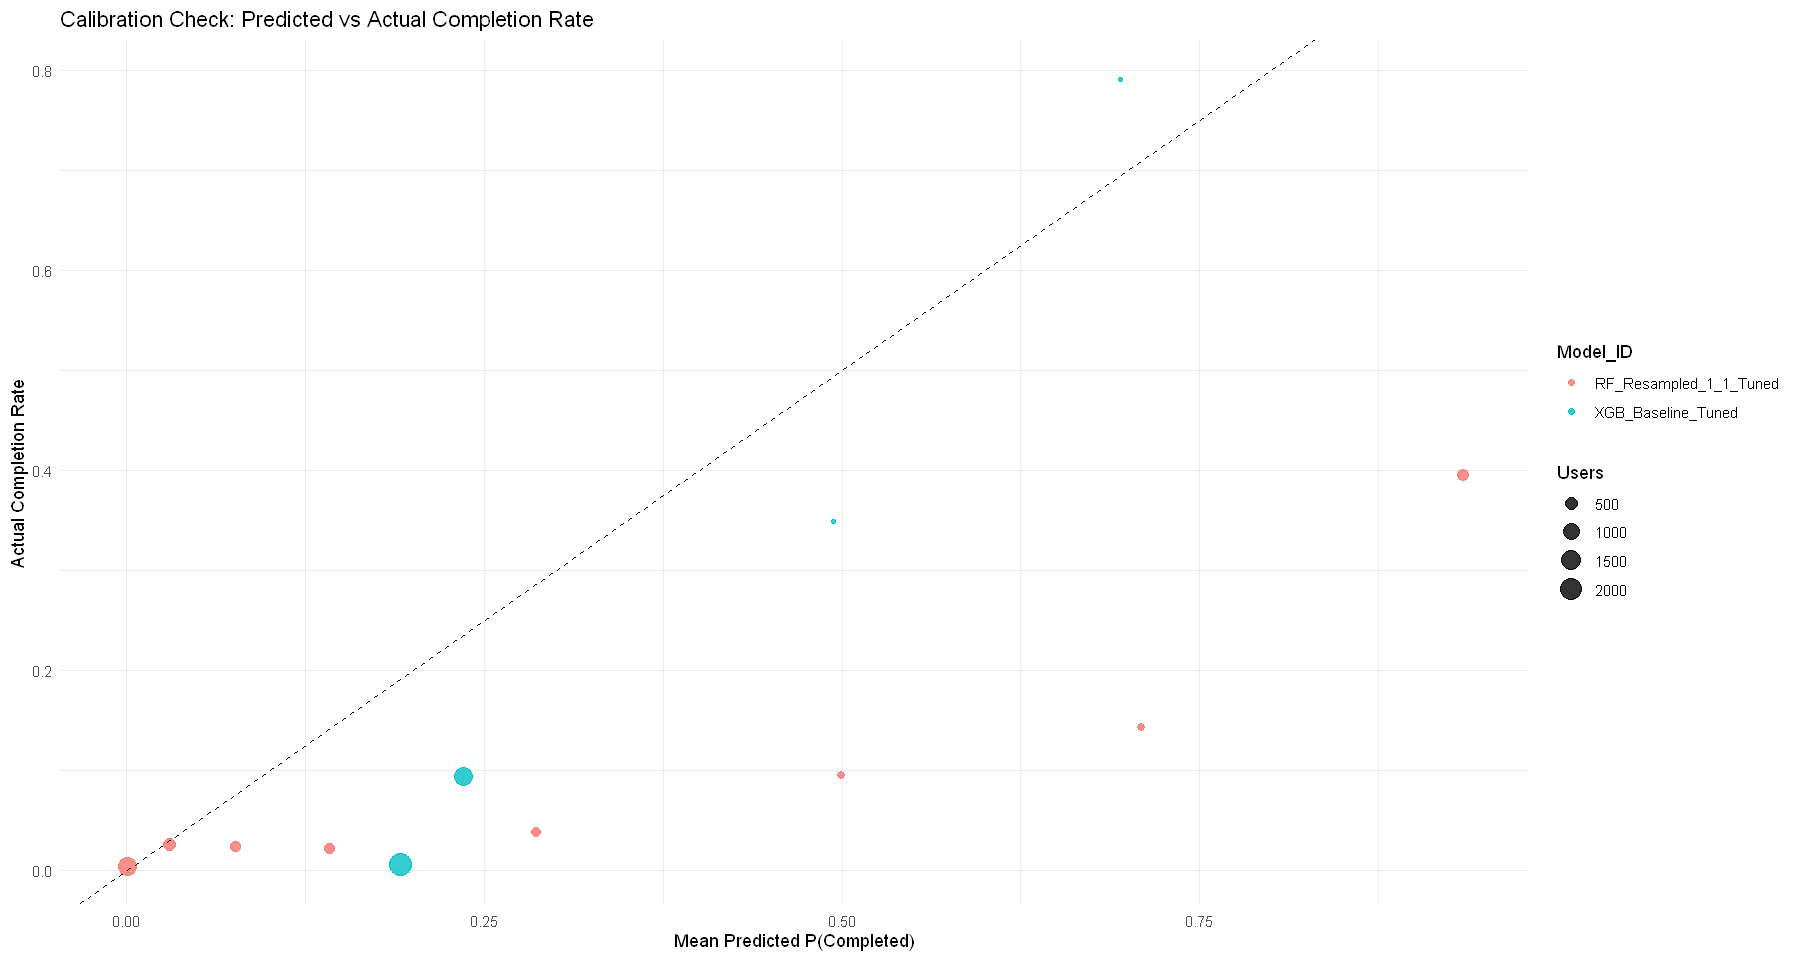

In [122]:
# Visualize calibration by comparing predicted probability bins
# with the observed completion rate in each bin.
ggplot(
  calibration_test_results,
  aes(
    x = Mean_P_Completed,
    y = Actual_Completion_Rate,
    color = Model_ID
  )
) +
  # Point size reflects the number of users in each probability bin.
  geom_point(aes(size = Users), alpha = 0.8) +
  
  # Reference line for perfect calibration:
  # predicted probability equals observed completion rate.
  geom_abline(
    intercept = 0,
    slope = 1,
    linetype = "dashed"
  ) +
  
  labs(
    title = "Calibration Check: Predicted vs Actual Completion Rate",
    x = "Mean Predicted P(Completed)",
    y = "Actual Completion Rate",
    size = "Users"
  ) +
  theme_minimal()

**Visual Interpretation: Calibration Plot**

The dashed diagonal line represents perfect calibration: predicted `P(Completed)` would equal the observed completion rate. Points below the line indicate overestimation of completion probability.

The plot confirms that neither selected progress-aware model is perfectly calibrated. `XGB_Baseline_Tuned` is closer to the diagonal in several probability ranges, while `RF_Resampled_1_1_Tuned` shows stronger overconfidence, especially in higher predicted-probability bins.

The point size reflects the number of users in each bin. Larger low-probability bins are especially important because most users have low predicted completion probability under the severe class imbalance.

---

**Overall Calibration Summary**

The calibration diagnostics show that neither selected progress-aware model should be interpreted as producing perfectly calibrated literal probabilities. Both models overestimate the average probability of completion compared with the actual test-set completion rate of **6.6%**.

`XGB_Baseline_Tuned` is better calibrated than `RF_Resampled_1_1_Tuned` and is therefore more appropriate for probability-based ranking of `P(Completed)`. However, its probabilities are still used mainly as relative ranking scores rather than exact individual probabilities.

`RF_Resampled_1_1_Tuned` shows weaker calibration, especially in higher probability bins. This is expected because 1:1 class resampling changes the effective class distribution seen during training. Therefore, RF probabilities should be treated mainly as relative scores for threshold-oriented comparison, not as literal probabilities.

Calibration is used here only as a post-selection diagnostic. It does not change the already selected models or validation thresholds.

## Model Interpretation

> **Technical Note: Progress-Aware Feature Importance**
>
> After selecting and evaluating the final **progress-aware models**, this section interprets which early behavioral and progress-related features drive their predictions.
>
> The section focuses on two selected models:
>
> - `XGB_Baseline_Tuned` as the primary ranking-oriented model.
> - `RF_Resampled_1_1_Tuned` as the threshold-oriented intervention challenger.
>
> Feature importance is used to check whether the model logic is consistent with the Activation Gap identified earlier: weak practical activation, limited early progress, low productivity, and early inactivity should correspond to weaker completion signal.
>
> Importance values are model-specific and should not be compared directly across algorithms. XGBoost importance is reported using `Gain`, while Random Forest importance is reported using `MeanDecreaseGini`. Therefore, interpretation focuses on relative rankings and recurring high-importance features rather than absolute importance values.
>
> Random Forest `MeanDecreaseGini` can be biased toward continuous or high-cardinality predictors, so RF importance is interpreted cautiously and mainly at the broader feature-group level.
>
> Because these models include progress-related predictors, feature importance should be interpreted as evidence of early progress alignment with the score-based completion target, not as a fully leakage-free or causal explanation.

### Random Forest Feature Importance

In [123]:
# Use the selected RF challenger model for feature-importance analysis.
rf_final_model <- final_intervention_model

In [124]:
# Extract Random Forest feature importance.
# MeanDecreaseGini reflects how much each feature reduces node impurity across trees.
rf_importance <- randomForest::importance(rf_final_model)

# Convert RF importance output into a reporting table.
rf_importance_dt <- data.table(
  Feature = rownames(rf_importance),
  MeanDecreaseGini = rf_importance[, "MeanDecreaseGini"]
)

# Rank features from highest to lowest importance.
rf_importance_dt <- rf_importance_dt[
  order(-MeanDecreaseGini)
]

In [125]:
# Keep the top 10 features for compact interpretation.
rf_importance_top <- rf_importance_dt[1:10]

rf_importance_top

Feature,MeanDecreaseGini
<chr>,<dbl>
n_passed_practical,73.31917
n_passed_all,53.95795
n_viewed_all,47.05953
n_started_practical,46.55651
score_per_active_day,37.64981
n_submissions,32.44307
submissions_per_started_practical,21.52249
practical_pass_rate,18.27190
submissions_per_active_day,18.05775


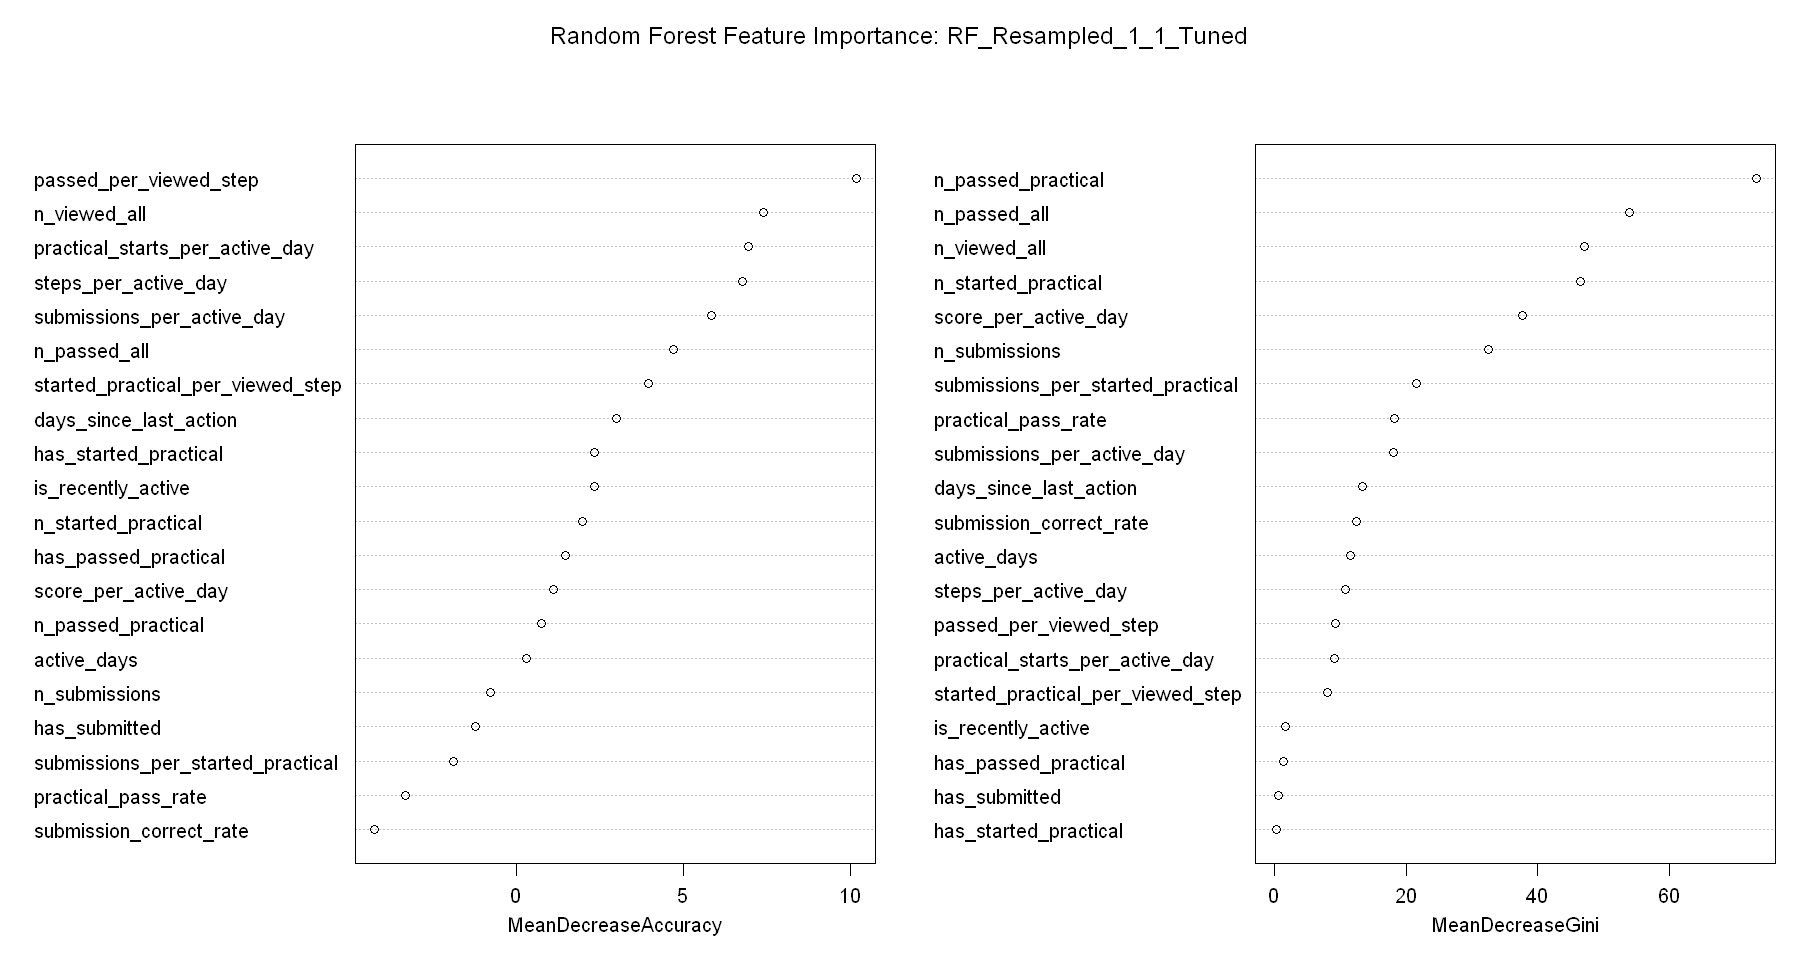

In [126]:
# Plot RF feature importance for the selected challenger model.
# The plot shows which engineered features contribute most to split decisions
# according to MeanDecreaseGini.
varImpPlot(
  rf_final_model,
  main = paste("Random Forest Feature Importance:", final_intervention_model_id)
)

**Visual Interpretation: Random Forest Feature Importance**

The Random Forest model shows a broader feature-importance pattern than XGBoost. Direct progress features remain important, but engineered intensity and ratio features also contribute strongly.

This supports interpreting the RF challenger as a progress-aware model that uses both early progress counts and relative practice-intensity signals. Because `MeanDecreaseGini` can be biased, the ranking is interpreted cautiously at the broader feature-group level.

### XGBoost Feature Importance

In [127]:
# Extract XGBoost feature importance for the tuned ranking model.
# Gain is used as the main importance measure because it reflects
# each feature's contribution to improving tree split quality.
xgb_importance <- xgboost::xgb.importance(
  feature_names = features_engineered,
  model = xgb_baseline_tuned
)

# Convert importance output to data.table for easier inspection and reporting.
xgb_importance_dt <- as.data.table(xgb_importance)

In [128]:
# Keep the top 10 most important features for compact interpretation.
xgb_importance_top <- xgb_importance_dt[1:10]

xgb_importance_top

Feature,Gain,Cover,Frequency
<chr>,<dbl>,<dbl>,<dbl>
n_passed_practical,0.838287866,0.591270477,0.28251121
days_since_last_action,0.070389206,0.047215758,0.16591928
practical_pass_rate,0.017592999,0.057605183,0.08520179
submissions_per_active_day,0.008784472,0.008846575,0.05605381
n_started_practical,0.008551913,0.003382218,0.02914798
n_viewed_all,0.008534224,0.075656681,0.06502242
submission_correct_rate,0.008053309,0.111023603,0.05381166
active_days,0.007632569,0.036268056,0.04932735
passed_per_viewed_step,0.007530746,0.009933891,0.04484305


**Visual Interpretation: XGBoost Feature Importance**

`n_passed_practical` is the dominant XGBoost feature, followed by broader progress and recency signals. This supports the progress-aware interpretation of the model: it mainly detects whether users are already moving toward the score-based completion threshold.

### Combined Feature Importance View

In [129]:
# Prepare comparable feature-importance rankings for XGBoost and Random Forest.
# Importance values are model-specific, so the combined table compares ranks
# rather than treating raw importance scores as directly comparable.
xgb_importance_ranked <- xgb_importance_dt[
  ,
  .(
    Feature,
    XGB_Gain = Gain
  )
]

In [130]:
# Rank XGBoost features by Gain.
xgb_importance_ranked[, XGB_Rank := frank(
  -XGB_Gain,
  ties.method = "min"
)]

rf_importance_ranked <- rf_importance_dt[
  ,
  .(
    Feature,
    RF_MeanDecreaseGini = MeanDecreaseGini
  )
]

In [131]:
# Rank Random Forest features by MeanDecreaseGini.
rf_importance_ranked[, RF_Rank := frank(
  -RF_MeanDecreaseGini,
  ties.method = "min"
)]

In [132]:
# Combine both model-specific importance rankings into one comparison table.
combined_importance <- merge(
  xgb_importance_ranked,
  rf_importance_ranked,
  by = "Feature",
  all = TRUE
)

# Sort by the best rank achieved in either model to surface features
# that are important for at least one selected model.
combined_importance <- combined_importance[
  order(pmin(XGB_Rank, RF_Rank, na.rm = TRUE))
]

# Display only the top features for reporting.
combined_importance_top <- combined_importance[
  1:min(.N, 15)
]

combined_importance_top

Feature,XGB_Gain,XGB_Rank,RF_MeanDecreaseGini,RF_Rank
<chr>,<dbl>,<int>,<dbl>,<int>
n_passed_practical,0.838287866,1,73.319175,1
days_since_last_action,0.070389206,2,13.377750,10
n_passed_all,0.007093795,10,53.957950,2
n_viewed_all,0.008534224,6,47.059534,3
practical_pass_rate,0.017592999,3,18.271897,8
n_started_practical,0.008551913,5,46.556515,4
submissions_per_active_day,0.008784472,4,18.057750,9
score_per_active_day,0.003418938,13,37.649805,5
n_submissions,0.001594628,14,32.443070,6


**Model Interpretation Summary**

The combined importance view confirms that both selected progress-aware models rely most strongly on early progress signals, especially `n_passed_practical` and `n_passed_all`.

At the same time, recency, activity volume, productivity, and submission-related features also appear among the important predictors. This supports the Activation Gap interpretation: weak practical activation and limited early progress are central indicators of later non-completion risk.

Because completion is score-based, this should be interpreted as progress-aware early monitoring evidence rather than as a fully leakage-free or causal explanation.

## Single-Feature Ablation: Removing n_passed_practical

> **Technical Note: Dominant Feature Ablation**
>
> `n_passed_practical` is the dominant progress-related feature in the selected progress-aware models and is closely aligned with the score-based completion target.
>
> This ablation removes `n_passed_practical` and retrains the selected model families to check whether performance depends mainly on this single feature or remains supported by broader early engagement, productivity, recency, and progress signals.
>
> The ablation is used as a sensitivity check, not as a separate model-selection cycle.

In [133]:
# Define the dominant progress-related feature to remove for the ablation check.
dominant_feature <- "n_passed_practical"

# Create a reduced progress-aware feature set without the dominant predictor.
features_without_dominant <- setdiff(
  features_engineered,
  dominant_feature
)

In [134]:
# Validate that the dominant feature was removed and all remaining features exist.
stopifnot(!dominant_feature %in% features_without_dominant)
stopifnot(all(features_without_dominant %in% names(train_data_engineered)))

### Random Forest Ablation: Without n_passed_practical

In [135]:
# Configure the RF ablation model using the same tuned 1:1 resampling setup,
# but with n_passed_practical removed from the feature set.
rf_no_dominant_args <- list(
  x = train_data_engineered[, ..features_without_dominant],
  y = train_data_engineered$completion_status,
  ntree = 500,
  mtry = best_rf_params$mtry,
  nodesize = best_rf_params$nodesize,
  importance = TRUE,
  strata = train_data_engineered$completion_status,
  sampsize = rf_sampsize_1_1_tune
)

# Apply maxnodes only if the selected RF tuning configuration includes it.
if (!is.na(best_rf_params$maxnodes)) {
  rf_no_dominant_args$maxnodes <- best_rf_params$maxnodes
}

In [136]:
# Refit Random Forest without the dominant progress feature.
set.seed(42)
rf_no_dominant <- do.call(
  randomForest::randomForest,
  rf_no_dominant_args
)

In [137]:
# Predict validation probabilities using the reduced feature set.
rf_no_dominant_probs_val <- predict(
  rf_no_dominant,
  newdata = val_data_engineered[, ..features_without_dominant],
  type = "prob"
)[, positive_class]

In [138]:
# Evaluate the reduced-feature RF model on validation data.
rf_no_dominant_val_result <- evaluate_validation_model(
  probs_val = rf_no_dominant_probs_val,
  val_truth = val_data_engineered$completion_status,
  optimize_metric = "F2",
  positive_class = positive_class
)

In [139]:
# Label the result for ablation comparison tables.
rf_no_dominant_val_result[, `:=`(
  Feature_Set = "Progress_Aware_No_n_passed_practical",
  Model_ID = "RF_Resampled_1_1"
)]

### XGBoost Ablation: Without n_passed_practical

In [140]:
# Prepare reduced XGBoost matrices after removing the dominant progress feature.
dtrain_no_dominant <- make_xgb_dmatrix_generic(
  train_data_engineered,
  features_without_dominant
)

dval_no_dominant <- make_xgb_dmatrix_generic(
  val_data_engineered,
  features_without_dominant
)

In [141]:
# Refit XGBoost with the same tuned parameters, but without n_passed_practical.
# This isolates how much validation performance depends on the dominant feature.
set.seed(42)

xgb_no_dominant <- xgboost::xgb.train(
  params = xgb_final_params,
  data = dtrain_no_dominant,
  nrounds = best_nrounds,
  watchlist = list(train = dtrain_no_dominant, val = dval_no_dominant),
  maximize = TRUE,
  verbose = 0
)

In [142]:
# Predict validation probabilities using the reduced feature set.
xgb_no_dominant_probs_val <- predict(xgb_no_dominant, dval_no_dominant)

In [143]:
# Evaluate the reduced-feature XGBoost model on validation data.
xgb_no_dominant_val_result <- evaluate_validation_model(
  probs_val = xgb_no_dominant_probs_val,
  val_truth = val_data_engineered$completion_status,
  optimize_metric = "F2",
  positive_class = positive_class
)


In [144]:
# Label the result for ablation comparison tables.
xgb_no_dominant_val_result[, `:=`(
  Feature_Set = "Progress_Aware_No_n_passed_practical",
  Model_ID = "XGB_Baseline"
)]

### Dominant Feature Ablation Comparison

In [145]:
# Combine full and ablated validation results for the selected tuned models.
# This compares model performance with and without the dominant progress feature.
dominant_feature_ablation_comparison <- rbindlist(
  list(
    xgb_baseline_tuned_val_result,
    rf_resampled_1_1_tuned_val_result,
    xgb_no_dominant_val_result,
    rf_no_dominant_val_result
  ),
  use.names = TRUE,
  fill = TRUE
)

In [146]:
# Create a compact reporting table focused on the main validation metrics.
dominant_feature_ablation_comparison_compact <- dominant_feature_ablation_comparison[
  ,
  .(
    Feature_Set,
    Model_ID,
    Threshold = Val_Threshold,
    ROC_AUC = Val_ROC_AUC,
    PR_AUC = Val_PR_AUC,
    Recall = Val_Recall,
    Precision = Val_Precision,
    F2 = Val_F2,
    FPR = Val_FPR
  )
]

dominant_feature_ablation_comparison_compact

Feature_Set,Model_ID,Threshold,ROC_AUC,PR_AUC,Recall,Precision,F2,FPR
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Progress_Aware_Tuned,XGB_Baseline_Tuned,0.29,0.9090,0.6205,0.691,0.491,0.639,0.051
Progress_Aware_Tuned,RF_Resampled_1_1_Tuned,0.80,0.8986,0.5263,0.712,0.444,0.636,0.063
Progress_Aware_No_n_passed_practical,XGB_Baseline,0.29,0.9042,0.5992,0.691,0.451,0.625,0.059
Progress_Aware_No_n_passed_practical,RF_Resampled_1_1,0.79,0.8961,0.4496,0.708,0.438,0.630,0.064


**Dominant Progress-Feature Ablation Summary**

To assess whether the progress-aware models depend too strongly on one dominant predictor, an additional ablation check was performed by removing `n_passed_practical` from the engineered feature set.

The results show that model performance decreases moderately after removing this feature. For XGBoost, validation PR-AUC decreases from 0.6205 to 0.5992, while F2 decreases from 0.639 to 0.625. For Random Forest, F2 remains very close to the tuned progress-aware model result (0.636 vs. 0.630), although PR-AUC decreases more clearly from 0.5263 to 0.4496.

This suggests that `n_passed_practical` is the strongest individual progress-aware predictor, but the models are not driven by this feature alone. After its removal, predictive signal is redistributed to related early progress and engagement variables such as `n_passed_all`, `n_started_practical`, activity volume, productivity, and recency.

Overall, this ablation check supports the interpretation that the main models rely on a broader progress-aware feature family rather than a single dominant variable. At the same time, the performance drop confirms that progress-related predictors contribute meaningfully to model quality. The next feature-importance check examines where the predictive signal shifts after removing `n_passed_practical`.

---

## Feature Importance After Removing the Dominant Progress Feature

> **Technical Note: Dominant Feature Ablation**
>
> `n_passed_practical` is the dominant progress-related feature in the selected progress-aware models and is closely aligned with the score-based completion target.
>
> This ablation removes `n_passed_practical` and retrains the selected model families to check whether performance depends mainly on this single feature or remains supported by broader early engagement, productivity, recency, and progress signals.
>
> The ablation is used as a sensitivity check, not as a separate model-selection cycle.

In [147]:
# Extract feature importance from the RF ablation model.
# This shows which predictors become most important after removing
# the dominant progress feature n_passed_practical.
rf_no_dominant_importance <- randomForest::importance(rf_no_dominant)

# Convert RF importance output into a reporting table.
rf_no_dominant_importance_dt <- data.table(
  Feature = rownames(rf_no_dominant_importance),
  MeanDecreaseGini = rf_no_dominant_importance[, "MeanDecreaseGini"]
)

In [148]:
# Extract feature importance from the RF ablation model.
# This shows which predictors become most important after removing
# the dominant progress feature n_passed_practical.
rf_no_dominant_importance <- randomForest::importance(
  rf_no_dominant
)

rf_no_dominant_importance_dt <- data.table(
  Feature = rownames(rf_no_dominant_importance),
  MeanDecreaseGini = rf_no_dominant_importance[, "MeanDecreaseGini"]
)

In [149]:
# Extract feature importance from the XGBoost ablation model.
# This shows which predictors become most important after removing
# the dominant progress feature n_passed_practical.
xgb_no_dominant_importance <- xgboost::xgb.importance(
  feature_names = features_without_dominant,
  model = xgb_no_dominant
)

# Convert importance output to data.table for reporting.
xgb_no_dominant_importance_dt <- as.data.table(xgb_no_dominant_importance)

In [150]:
# Prepare comparable feature-importance rankings for the ablation models.
# As before, raw XGBoost Gain and RF MeanDecreaseGini are model-specific,
# so ranks are compared instead of treating raw values as directly equivalent.
xgb_no_dominant_importance_ranked <- xgb_no_dominant_importance_dt[
  ,
  .(
    Feature,
    XGB_Gain = Gain
  )
]

In [151]:
# Rank XGBoost ablation features by Gain.
xgb_no_dominant_importance_ranked[, XGB_Rank := frank(
  -XGB_Gain,
  ties.method = "min"
)]

rf_no_dominant_importance_ranked <- rf_no_dominant_importance_dt[
  ,
  .(
    Feature,
    RF_MeanDecreaseGini = MeanDecreaseGini
  )
]

# Rank RF ablation features by MeanDecreaseGini.
rf_no_dominant_importance_ranked[, RF_Rank := frank(
  -RF_MeanDecreaseGini,
  ties.method = "min"
)]

In [152]:
# Combine XGBoost and RF ablation importance rankings into one table.
combined_importance_no_dominant <- merge(
  xgb_no_dominant_importance_ranked,
  rf_no_dominant_importance_ranked,
  by = "Feature",
  all = TRUE
)

# Sort by the best rank achieved in either ablation model.
combined_importance_no_dominant <- combined_importance_no_dominant[
  order(pmin(XGB_Rank, RF_Rank, na.rm = TRUE))
]

# Keep a compact top-feature view for reporting.
combined_importance_no_dominant_top <- combined_importance_no_dominant[1:10]

combined_importance_no_dominant_top

Feature,XGB_Gain,XGB_Rank,RF_MeanDecreaseGini,RF_Rank
<chr>,<dbl>,<int>,<dbl>,<int>
n_passed_all,0.5650912880,1,71.044968,1
n_started_practical,0.2326487486,2,56.072277,2
days_since_last_action,0.0752597815,3,14.207679,11
n_viewed_all,0.0067884887,10,51.112718,3
n_submissions,0.0101720575,7,46.647372,4
practical_pass_rate,0.0601213649,4,20.444310,7
score_per_active_day,0.0110982275,6,42.387941,5
started_practical_per_viewed_step,0.0117037124,5,8.582932,15
submissions_per_started_practical,0.0008918459,13,23.970060,6


**Ablation Feature Importance Summary**

After removing the dominant progress feature `n_passed_practical`, both models continue to rely on related early progress and practical-engagement signals.

The strongest replacement predictors are `n_passed_all` and `n_started_practical`. This shows that the original model signal was not driven by one isolated feature only; however, the main predictive signal still comes from the broader progress-aware feature family.

For XGBoost, `days_since_last_action` remains highly important, suggesting that recency provides additional behavioral signal beyond direct progress accumulation. Random Forest relies more strongly on broader activity-volume and productivity features such as `n_viewed_all`, `n_submissions`, and `score_per_active_day`.

Overall, the ablation confirms that `n_passed_practical` is the single strongest progress proxy, but removing it does not eliminate predictive structure. The models redistribute importance to other progress-aware predictors. Therefore, the main model should still be interpreted as **progress-aware early monitoring**, not as a leakage-free future-prediction setup.

---

## Leakage-Reduced Feature Set Robustness Check

> **Technical Note: Leakage-Reduced Robustness Check**
>
> The main models are **progress-aware**: they use early engagement together with progress-, pass-, submission-, success-, and productivity-related features. Because completion is defined by reaching at least 75 points, some of these variables may act as target proxies.
>
> This section evaluates a **leakage-reduced engagement-only feature set**. Direct score/progress proxy variables are removed, while general engagement, recency, and practical-start behavior are retained.
>
> This is not a second full model-selection cycle. The engagement-only models reuse the same train/validation/test split and validation-based threshold selection logic as the main workflow. Therefore, the results are interpreted as a robustness check, not as an independently optimized alternative modeling pipeline.
>
> The goal is to assess whether early behavioral engagement still carries predictive signal after reducing target-proxy risk.

In [153]:
# Practical-start variables are retained because they represent activation and engagement behavior rather than successful completion, score accumulation, or passed-step progress. 
# In contrast, passed, score, submission-success, and productivity variables are removed as direct progress proxies.
engagement_only_features <- c(
  "n_viewed_all",
  "n_started_practical",
  "active_days",
  "days_since_last_action",
  "has_started_practical",
  "is_recently_active",
  "started_practical_per_viewed_step",
  "practical_starts_per_active_day"
)

# Features that should not be included in the leakage-reduced feature set
# because they directly reflect score, pass, submission success, or progress.
progress_proxy_features <- c(
  "n_passed_all",
  "n_passed_practical",
  "n_submissions",
  "submission_correct_rate",
  "score_per_active_day",
  "steps_per_active_day",
  "has_submitted",
  "has_passed_practical",
  "practical_pass_rate",
  "submissions_per_started_practical",
  "passed_per_viewed_step",
  "submissions_per_active_day"
)

stopifnot(all(engagement_only_features %in% names(train_data_engineered)))
stopifnot(!any(progress_proxy_features %in% engagement_only_features))

---

### Engagement-Only Random Forest Validation Check

In [154]:
# Count class sizes in the training data used for the engagement-only RF model.
rf_clean_class_counts <- table(train_data_engineered$completion_status)

In [155]:
# Identify the majority / negative class dynamically.
# This keeps the code robust as long as `positive_class` is defined consistently.
negative_class <- setdiff(
  levels(train_data_engineered$completion_status),
  positive_class
)

In [156]:
# Store class counts for the positive and negative classes.
n_pos_clean <- as.integer(rf_clean_class_counts[positive_class])
n_neg_clean <- as.integer(rf_clean_class_counts[negative_class])

In [157]:
# Create a named sampling-size vector required by randomForest::randomForest().
# The goal is 1:1 stratified sampling:
# keep all Completed users and sample the same number of Not_Completed users.
rf_clean_sampsize_1_1 <- setNames(
  integer(length(levels(train_data_engineered$completion_status))),
  levels(train_data_engineered$completion_status)
)

In [158]:
# Keep all available positive-class users.
rf_clean_sampsize_1_1[positive_class] <- n_pos_clean

In [159]:
# Downsample the negative class to match the positive-class count.
# `min()` protects the code in case the negative class is ever smaller.
rf_clean_sampsize_1_1[negative_class] <- min(n_neg_clean, n_pos_clean)

In [160]:
# Train the engagement-only RF model using the reduced feature set.
# This serves as a leakage-reduced robustness check against progress-aware models.
set.seed(42)
rf_clean <- randomForest::randomForest(
  x = train_data_engineered[, ..engagement_only_features],
  y = train_data_engineered$completion_status,
  ntree = 500,
  mtry = floor(sqrt(length(engagement_only_features))),
  importance = TRUE,
  strata = train_data_engineered$completion_status,
  sampsize = rf_clean_sampsize_1_1
)

In [161]:
# Predict validation probabilities for the positive class.
rf_clean_probs_val <- predict(
  rf_clean,
  newdata = val_data_engineered[, ..engagement_only_features],
  type = "prob"
)[, positive_class]

# Sanity check: predicted probabilities must stay within valid probability bounds.
stopifnot(all(rf_clean_probs_val >= 0 & rf_clean_probs_val <= 1))

In [162]:
# Evaluate the engagement-only RF model on validation data.
rf_clean_val_result <- evaluate_validation_model(
  probs_val = rf_clean_probs_val,
  val_truth = val_data_engineered$completion_status,
  optimize_metric = "F2",
  positive_class = positive_class
)

# Label the result for robustness-check comparison tables.
rf_clean_val_result[, `:=`(
  Feature_Set = "Engagement_Only",
  Model_ID =  "RF_Resampled_1_1"
)]

### Engagement-Only XGBoost Validation Check

In [163]:
# Prepare XGBoost matrices for the engagement-only feature set.
# The test matrix is created here as well so the same feature structure
# can be reused later during final holdout evaluation if needed.
dtrain_clean <- make_xgb_dmatrix_generic(
  train_data_engineered,
  engagement_only_features
)

dval_clean <- make_xgb_dmatrix_generic(
  val_data_engineered,
  engagement_only_features
)

dtest_clean <- make_xgb_dmatrix_generic(
  test_data_engineered,
  engagement_only_features
)

In [164]:
# Define a baseline XGBoost configuration for the engagement-only robustness check.
xgb_clean_params <- list(
  objective = "binary:logistic",
  eval_metric = "aucpr",
  eta = 0.05,
  max_depth = 4,
  min_child_weight = 1,
  subsample = 0.8,
  colsample_bytree = 0.8,
  nthread = 1
)

In [165]:
# Train the engagement-only XGBoost model with validation monitoring.
# This checks how much predictive signal remains after removing
# direct progress- and score-based proxy features.
set.seed(42)
xgb_clean <- xgboost::xgb.train(
  params = xgb_clean_params,
  data = dtrain_clean,
  nrounds = 500,
  watchlist = list(train = dtrain_clean, val = dval_clean),
  early_stopping_rounds = 30,
  maximize = TRUE,
  verbose = 0
)

# Predict validation probabilities for the positive class.
xgb_clean_probs_val <- predict(xgb_clean, dval_clean)

# Sanity check: predicted probabilities must stay within valid probability bounds.
stopifnot(all(xgb_clean_probs_val >= 0 & xgb_clean_probs_val <= 1))

In [166]:
# Evaluate the engagement-only XGBoost model on validation data.
xgb_clean_val_result <- evaluate_validation_model(
  probs_val = xgb_clean_probs_val,
  val_truth = val_data_engineered$completion_status,
  optimize_metric = "F2",
  positive_class = positive_class
)

# Label the result for robustness-check comparison tables.
xgb_clean_val_result[, `:=`(
  Feature_Set = "Engagement_Only",
  Model_ID = "XGB_Baseline"
)]

### Engagement-Only Robustness Comparison

In [167]:
# Combine validation results from the progress-aware tuned models
# and the leakage-reduced engagement-only robustness checks.
clean_validation_comparison <- rbindlist(
  list(
    xgb_baseline_tuned_val_result,
    rf_resampled_1_1_tuned_val_result,
    xgb_clean_val_result,
    rf_clean_val_result
  ),
  use.names = TRUE,
  fill = TRUE
)

In [168]:
# Create a compact comparison table focused on the main validation metrics.
# This table shows how much performance remains after removing direct
# progress- and score-based proxy features.
clean_validation_comparison_compact <- clean_validation_comparison[
  ,
  .(
    Feature_Set,
    Model_ID,
    Threshold = Val_Threshold,
    ROC_AUC = Val_ROC_AUC,
    PR_AUC = Val_PR_AUC,
    Recall = Val_Recall,
    Precision = Val_Precision,
    F2 = Val_F2,
    FPR = Val_FPR
  )
]

clean_validation_comparison_compact

Feature_Set,Model_ID,Threshold,ROC_AUC,PR_AUC,Recall,Precision,F2,FPR
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Progress_Aware_Tuned,XGB_Baseline_Tuned,0.29,0.9090,0.6205,0.691,0.491,0.639,0.051
Progress_Aware_Tuned,RF_Resampled_1_1_Tuned,0.80,0.8986,0.5263,0.712,0.444,0.636,0.063
Engagement_Only,XGB_Baseline,0.19,0.8923,0.5352,0.674,0.406,0.595,0.070
Engagement_Only,RF_Resampled_1_1,0.64,0.8853,0.5276,0.695,0.370,0.591,0.084


**Result Summary: Engagement-Only Validation Robustness Check**

The selected progress-aware models remain stronger overall than the engagement-only alternatives. `XGB_Baseline_Tuned` provides the strongest validation ranking quality, while `RF_Resampled_1_1_Tuned` remains a useful threshold-oriented challenger.

After removing direct progress proxies, performance decreases, but the engagement-only models still retain meaningful signal. This supports the robustness check: early engagement, recency, and practical-start behavior contribute predictive value beyond direct score/progress accumulation.

These metrics are validation-stage diagnostics only. Final robustness performance is evaluated separately on the reserved test set.

---

# Engagement-Only Final Holdout Robustness Check

> **Technical Note: Engagement-Only Holdout Robustness Check**
>
> This section evaluates the engagement-only models on the reserved test set after removing direct score/progress proxy features. The goal is not to select a new final model, but to check whether early engagement, recency, and practical-start behavior still retain predictive signal on unseen users.
>
> Validation-selected thresholds are applied unchanged to the test set.

In [169]:
### Engagement-Only Test Evaluation: Random Forest

In [170]:
# Predict final holdout probabilities for the engagement-only RF model.
rf_clean_probs_test <- predict(
  rf_clean,
  newdata = test_data_engineered[, ..engagement_only_features],
  type = "prob"
)[, positive_class]

# Sanity check: predicted probabilities must stay within valid probability bounds.
stopifnot(all(rf_clean_probs_test >= 0 & rf_clean_probs_test <= 1))

In [171]:
# Evaluate engagement-only RF on the reserved test set
# using the threshold selected on validation data.
rf_clean_test_result <- evaluate_final_test_model(
  probs_test = rf_clean_probs_test,
  test_truth = test_data_engineered$completion_status,
  threshold = rf_clean_val_result$Val_Threshold,
  positive_class = positive_class
)

# Label the result for final robustness comparison.
rf_clean_test_result[, `:=`(
  Feature_Set = "Engagement_Only",
  Model_ID = "RF_Resampled_1_1"
)]

### Engagement-Only Test Evaluation: XGBoost

In [172]:
# Predict final holdout probabilities for the engagement-only XGBoost model.
xgb_clean_probs_test <- predict(xgb_clean, dtest_clean)

# Sanity check: predicted probabilities must stay within valid probability bounds.
stopifnot(all(xgb_clean_probs_test >= 0 & xgb_clean_probs_test <= 1))

In [173]:
# Evaluate engagement-only XGBoost on the reserved test set
# using the threshold selected on validation data.
xgb_clean_test_result <- evaluate_final_test_model(
  probs_test = xgb_clean_probs_test,
  test_truth = test_data_engineered$completion_status,
  threshold = xgb_clean_val_result$Val_Threshold,
  positive_class = positive_class
)

# Label the result for final robustness comparison.
xgb_clean_test_result[, `:=`(
  Feature_Set = "Engagement_Only",
  Model_ID = "XGB_Baseline"
)]

### Progress-Aware vs Engagement-Only Test Comparison

In [174]:
# Add feature-set labels to the already evaluated progress-aware models.
# This makes them comparable with the engagement-only test results.
rf_final_test_result[, Feature_Set := "Progress_Aware_Tuned"]
xgb_final_test_result[, Feature_Set := "Progress_Aware_Tuned"]

In [175]:
# Combine progress-aware and engagement-only final test results.
# This checks how much holdout performance remains after removing
# direct progress- and score-based proxy features.
clean_test_results <- rbindlist(
  list(
    rf_final_test_result,
    xgb_final_test_result,
    xgb_clean_test_result,
    rf_clean_test_result
  ),
  use.names = TRUE,
  fill = TRUE
)

In [176]:
# Display a compact final holdout comparison table.
clean_test_results[
  ,
  .(
    Feature_Set,
    Model_ID,
    Threshold,
    Test_ROC_AUC,
    Test_PR_AUC,
    Test_Recall,
    Test_Precision,
    Test_F2,
    Test_FPR
  )
]

Feature_Set,Model_ID,Threshold,Test_ROC_AUC,Test_PR_AUC,Test_Recall,Test_Precision,Test_F2,Test_FPR
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Progress_Aware_Tuned,RF_Resampled_1_1_Tuned,0.80,0.8953,0.4143,0.652,0.395,0.577,0.071
Progress_Aware_Tuned,XGB_Baseline_Tuned,0.29,0.9008,0.5460,0.618,0.403,0.559,0.065
Engagement_Only,XGB_Baseline,0.19,0.8917,0.5090,0.635,0.369,0.555,0.077
Engagement_Only,RF_Resampled_1_1,0.64,0.8835,0.4739,0.622,0.336,0.532,0.087


**Result Summary: Engagement-Only Final Holdout Robustness Check**

The final holdout comparison confirms the expected trade-off: the selected progress-aware models perform strongest overall, while the engagement-only models remain informative after direct score/progress proxy features are removed.

`XGB_Baseline_Tuned` remains the strongest ranking-oriented model, with the highest test `ROC_AUC` and `PR_AUC`. The engagement-only XGBoost model performs weaker, but still retains meaningful ranking signal, suggesting that early engagement, recency, and practical-start behavior contribute beyond direct progress accumulation.

For Random Forest, the engagement-only version loses more threshold-based strength: `Recall`, `Precision`, and `F2` are lower, while `FPR` is higher than for `RF_Resampled_1_1_Tuned`.

Overall, the robustness check supports the main conclusion: the strongest operational performance comes from the progress-aware models, but the prediction task is not driven only by direct score/progress variables. Early engagement behavior still carries independent predictive value.

For business use, the completion-likelihood score is interpreted as a ranking signal and inverted into non-completion risk:

`Risk_Not_Completed = 1 - P(Completed)`

---

## Reproducibility: Model and Results Registry

> **Technical Note: Model and Results Registry**
>
> This section collects the main trained model objects and result tables created throughout the workflow. It is included for reproducibility, auditability, and easier inspection of final modeling artifacts.
>
> The registry is not used for model selection. Model selection has already been completed using validation-development results, and final performance has already been assessed on the reserved test set.

In [177]:
# Store all trained model objects in one list.
# This keeps the notebook output organized and makes it easier
# to save, inspect, or reuse selected models later.
all_model_objects <- list(
  baseline_models_original = models_original,
  baseline_models_engineered = models_engineered,
  
  tuned_model_rf_progress_aware = rf_resampled_1_1_tuned,
  tuned_model_xgb_progress_aware = xgb_baseline_tuned,
  
  final_model_intervention_challenger = final_intervention_model,
  final_model_ranking = final_ranking_model,
  
  ablation_model_rf_no_dominant = rf_no_dominant,
  ablation_model_xgb_no_dominant = xgb_no_dominant,
  
  robustness_model_rf_engagement_only = rf_clean,
  robustness_model_xgb_engagement_only = xgb_clean
)


# Store all important result tables in one list.
# Full tuning and importance tables are kept for reproducibility and audit;
# compact top/best tables are kept for easier reporting and review.
all_result_tables <- list(
  validation_results_original = baseline_results_validation,
  validation_results_engineered = engineered_results_validation,
  
  tuning_results_rf_full = rf_tuning_results,
  tuning_best_rf = best_rf_params_compact,
  tuning_results_xgb_full = xgb_tuning_results,
  tuning_best_xgb = best_xgb_params_compact,
  tuning_comparison_validation = tuning_comparison_val_compact,
  
  final_model_selection = final_model_selection,
  test_results_progress_aware = final_test_results,
  
  policy_results_high_risk = policy_test_results,
  policy_results_high_completion = completion_priority_test_results,
  
  calibration_bins_test = calibration_test_results,
  calibration_summary_test = calibration_summary_test,
  
  importance_progress_aware_full = combined_importance,
  importance_progress_aware_top = combined_importance_top,
  
  ablation_results_no_dominant = dominant_feature_ablation_comparison_compact,
  ablation_importance_no_dominant_full = combined_importance_no_dominant,
  ablation_importance_no_dominant_top = combined_importance_no_dominant_top,
  
  robustness_results_validation = clean_validation_comparison_compact,
  robustness_results_test = clean_test_results
)


# Quick inventory check of stored model objects and result tables.
names(all_model_objects)
names(all_result_tables)

[1] "baseline_models_original"            
 [2] "baseline_models_engineered"          
 [3] "tuned_model_rf_progress_aware"       
 [4] "tuned_model_xgb_progress_aware"      
 [5] "final_model_intervention_challenger" 
 [6] "final_model_ranking"                 
 [7] "ablation_model_rf_no_dominant"       
 [8] "ablation_model_xgb_no_dominant"      
 [9] "robustness_model_rf_engagement_only" 
[10] "robustness_model_xgb_engagement_only"

[1] "validation_results_original"         
 [2] "validation_results_engineered"       
 [3] "tuning_results_rf_full"              
 [4] "tuning_best_rf"                      
 [5] "tuning_results_xgb_full"             
 [6] "tuning_best_xgb"                     
 [7] "tuning_comparison_validation"        
 [8] "final_model_selection"               
 [9] "test_results_progress_aware"         
[10] "policy_results_high_risk"            
[11] "policy_results_high_completion"      
[12] "calibration_bins_test"               
[13] "calibration_summary_test"            
[14] "importance_progress_aware_full"      
[15] "importance_progress_aware_top"       
[16] "ablation_results_no_dominant"        
[17] "ablation_importance_no_dominant_full"
[18] "ablation_importance_no_dominant_top" 
[19] "robustness_results_validation"       
[20] "robustness_results_test"

In [178]:
# Export Model Objects and Result Tables
model_output_dir <- file.path(project_root, "models")
results_output_dir <- file.path(project_root, "results")

dir.create(model_output_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(results_output_dir, showWarnings = FALSE, recursive = TRUE)

In [179]:
# Save all model objects as one RDS file
saveRDS(
  all_model_objects,
  file = file.path(model_output_dir, "completion_risk_model_objects.rds")
)

# Save all result tables as one RDS file
saveRDS(
  all_result_tables,
  file = file.path(results_output_dir, "completion_risk_result_tables.rds")
)

## Business Risk Scoring and Retention Strategy

The final model output can be translated into a practical retention score:

`Risk_Not_Completed = 1 - P(Completed)`

Although the models are technically trained to predict `Completed`, this is intentional because `Completed` is the rare and more informative class. For retention use, the score is inverted: users with the lowest predicted `P(Completed)` are treated as the highest non-completion risk.

The score should be interpreted as a **progress-aware risk-ranking signal**, not as a hard binary prediction or perfectly calibrated probability. It uses first-10-day behavior and progress signals to identify users who already appear clearly on or off track.

**Intervention tiers**

| Risk tier | Suggested segment | Behavioral profile | Recommended intervention |
|---|---|---|---|
| Critical risk | Top 5% highest risk | Very weak early progress, little or no practical activation, likely early inactivity | Immediate nudge, first-task prompt, simplified entry path |
| High risk | Top 10% highest risk | Weak progress accumulation and limited practical engagement | Onboarding support, first-submission guidance, skeleton code |
| Medium-high risk | Top 20% highest risk | Some activity, but unstable progress or engagement | Progress feedback, next-step recommendation, task hints |
| Broad risk pool | Top 30% highest risk | Elevated risk with weaker early completion trajectory | Low-cost automated campaign, reactivation reminder |
| Lower risk | Remaining users | Stronger predicted completion probability or more stable engagement | Minimal intervention; optional achievement-oriented motivation |

**Operational model roles**

`XGB_Baseline_Tuned` is the primary **ranking-oriented model**. It is best suited for ranking users by `P(Completed)` and deriving the inverted non-completion risk score. Its probabilities are better calibrated than the Random Forest model, but should still be interpreted mainly as ranking scores.

`RF_Resampled_1_1_Tuned` is retained as a **threshold-oriented challenger**. It provides a stronger threshold-based trade-off for detecting completion signal, especially through Recall and F2 for the rare `Completed` class. Operationally, it can support broader recall-oriented intervention scenarios, but its probabilities should be treated as relative scores rather than calibrated probabilities.

**Robustness qualification**

The dominant-feature ablation shows that removing `n_passed_practical` weakens performance only moderately, so the progress-aware models are not driven by a single predictor alone.

The engagement-only robustness check shows that performance decreases after removing direct score/progress proxy features, but meaningful signal remains. This suggests that early progress explains part of the model performance, while engagement, recency, and practical-start behavior also carry independent predictive value.

In practice, `XGB_Baseline_Tuned` should be used as the primary risk-scoring model. `RF_Resampled_1_1_Tuned` can be monitored as a challenger model for broader intervention campaigns. The engagement-only models should not replace the primary models, but they support the conclusion that early user behavior contains useful retention signal beyond direct score accumulation.

## Final Project Conclusion

**1. Early behavior contains strong completion signal**

The project shows that early course behavior contains strong predictive signal for eventual completion. Even within the first 10 days, user activity patterns, early progress, practical activation, productivity, and recency help distinguish users who are on track to complete the course from users who are likely to disengage.

This finding directly supports the Activation Gap identified in the diagnostic phase: users are at higher risk when they fail to move from passive viewing into active practical engagement and measurable progress during the first 10 days.

**2. The main models are progress-aware, not fully leakage-free**

Because course completion is defined by reaching at least 75 points, the main models should be interpreted as **progress-aware completion risk models**. Some of the strongest predictors are directly related to early progress, passed steps, submissions, and score accumulation.

Therefore, the main model results do not represent a fully leakage-free future-prediction setting. Instead, they represent a practical early-progress monitoring approach that can identify whether users appear on track or at risk during the first 10 days.

**3. Feature engineering and tuning improved the progress-aware workflow**

Feature engineering improved the model comparison by making activation, behavioral-intensity, practical-success, and practice-intensity signals more explicit.

Targeted tuning improved the ranking-oriented XGBoost model mainly in terms of PR-AUC, supporting its role as the primary probability-based ranking model. For Random Forest, tuning improved the threshold-based trade-off for detecting completion signal, especially F2. Therefore, `RF_Resampled_1_1_Tuned` was retained as a threshold-oriented intervention challenger.

**4. Ablation and engagement-only checks qualify the results**

The ablation check removed the dominant progress feature `n_passed_practical`. Model performance decreased only moderately, suggesting that the progress-aware models are not driven by one predictor alone, but by a broader combination of early progress, engagement, productivity, and recency signals.

The leakage-reduced engagement-only robustness check provides an additional qualification. After removing direct score/progress proxy features, model performance generally decreases, but the engagement-only models still retain meaningful predictive signal. This suggests that early progress explains part of the model performance, while engagement, recency, and practical-start behavior also carry independent predictive value.

**5. Final model roles**

The final modeling strategy uses two complementary progress-aware models:

- `XGB_Baseline_Tuned` as the primary model for ranking users by `P(Completed)` and deriving the inverted non-completion risk score.
- `RF_Resampled_1_1_Tuned` as a threshold-oriented intervention challenger for broader retention scenarios, based on its stronger F2 trade-off for completion-signal detection.

In both cases, the models are evaluated technically as completion-prediction models, while business intervention targeting is based on the inverted score:

`Risk_Not_Completed = 1 - P(Completed)`

**6. Business interpretation**

From a business perspective, the model enables a shift from retrospective churn analysis to proactive retention management. Users can be scored during the first 10 days and assigned to risk-based intervention tiers before disengagement becomes permanent.

However, these scores should be interpreted as **progress-aware risk rankings**, not as perfectly calibrated probabilities or causal estimates of intervention effectiveness. The model should support retention prioritization, while future A/B testing would be required to evaluate whether specific interventions actually improve completion outcomes.

## Limitations and Future Work

**Production Limitations and Deployment Considerations**

Several limitations should be considered before using the model in a production retention workflow.

**1. Progress-aware target-proxy risk**

Course completion is defined by reaching at least 75 points. Therefore, some predictors — especially early progress-, pass-, score-, submission-, and success-related variables — are closely connected to the target definition.

During dataset preparation, 126 users, or about 0.71% of the modeling population, had already reached the completion threshold within the first 10-day observation window. This group is small, but it confirms that the main models should be interpreted as **progress-aware risk-ranking models**, not as fully leakage-free future-prediction models.

The `n_passed_practical` ablation check partly reduces this concern, because model performance remains meaningful after removing the single most dominant progress feature. However, it does not remove the broader progress-aware nature of the main models, since other pass-, activity-, and productivity-related predictors can still reflect early movement toward the completion threshold.

**2. Engagement-only robustness check**

To address the progress-proxy limitation, a leakage-reduced robustness check was performed using engagement-only features.

The engagement-only models performed weaker than the progress-aware models overall, but still retained meaningful predictive signal. This suggests that early progress explains part of the model performance, while engagement, recency, and practical-start behavior also provide independent signal.

**3. Probability calibration and score interpretation**

Predicted probabilities are used mainly for ranking rather than as perfectly calibrated probabilities.

The calibration check shows that `XGB_Baseline_Tuned` is better calibrated than `RF_Resampled_1_1_Tuned`, but even the XGBoost probabilities should be interpreted with caution.

Therefore:

- `XGB_Baseline_Tuned` is more appropriate for probability-based ranking of `P(Completed)`, which is later inverted into non-completion risk.
- `RF_Resampled_1_1_Tuned` should mainly be treated as a threshold-oriented intervention challenger with relative scores rather than calibrated probabilities.

**4. Validation-set reuse**

The validation set is used as a model-development set for several decisions, including feature-set comparison, model comparison, targeted hyperparameter tuning, threshold selection, and final model selection.

For this reason, validation metrics are interpreted as development diagnostics, while final performance is assessed on the reserved test set. Since threshold selection is also performed on the validation set, the selected thresholds should be revalidated before operational deployment, especially if intervention budgets or business cost assumptions change.

**5. Historical-course dependency**

The model is trained on historical data from a specific course period. If the course structure, scoring rules, platform design, or learner population changes, model performance should be monitored and revalidated.

This is especially important because progress-related predictors depend on how points and practical tasks are defined.

**6. Observation-window limitation**

The current model uses only the first 10 days of behavioral data. Future work could compare alternative observation windows, such as 3-day, 7-day, and 14-day windows, to determine the earliest reliable intervention point.

A stricter future-prediction setup should also define a fixed prediction timestamp and predict only future completion after that timestamp, for example among users who have not yet reached the 75-point threshold by day 10.

**7. No causal intervention estimate**

The model identifies users with high non-completion risk, but it does not estimate intervention effectiveness.

A future A/B test would be needed to measure whether nudges, skeleton code, reminders, onboarding support, or other interventions actually improve retention and completion outcomes.

**8. Production monitoring requirements**

Future production work should include monitoring for:

- data drift,
- probability calibration,
- model performance by user segment,
- changes in course structure or scoring logic,
- periodic retraining needs.

Overall, the model should be treated as a decision-support tool for prioritizing retention actions, not as a causal explanation of why individual users do or do not complete the course.